## Introduction to graphs in R

In this course we will work with networks using a small set of key R libraries. 

We will use **igraph** as the main tool to create and analyse networks, since it allows us to work with graphs, compute network metrics, and apply different algorithms. 

Data manipulation will be done using the **tidyverse**, which makes it easier to handle tables associated with networks. 

For visualisation, we will use **ggraph**, which allows flexible and clear network representations.
 
In addition, for ecological networks such as plant–pollinator systems, we will also use specialised packages like **bipartite**, designed specifically for the analysis of these types of networks.


### Importing the required libraries

In [1]:
# If needed (run once):
# install.packages(c("igraph","tidyverse","tidygraph","ggraph"))

library(igraph)
library(tidyverse)
library(tidygraph)
library(ggraph)
library(bipartite)

source("Functions.R") #include some helpers



Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%--%()      masks igraph::%--%()
✖ dplyr::as_data_frame() masks tibble::as_data_frame(), igraph::as_data_frame()
✖ purrr::compose()       masks igraph::compose()
✖ tidyr::crossing()      masks igraph::crossing()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ purrr::simplify()      masks igraph::simplify()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachin

# Part 1 

Here we will learn how to work start working with networks in R:

- Reading networks
- Simple visualization of networks

### Reading networks from adjaceny and incidence matrix files

As most networks are shared in these formats, the most comon way to import networks into your code will be by loading the csv as a dataframe and the converting that dataframe in a graph object, to work with igraph (or in a matrix to work with bipartite).
Let's see how we can import some real networks in here

#### Unipartite networks from adjacency matrices
*igraph* encodes all networks as unipertite, but it allows to create direct or undirected graphs.
Networks with only one type of nodes can be read from the $NxN$ Adjacency matrix ($A$) like this: 

*Note that you need a csv where the first row and column contains the names of the species. You should allways check that the structure matches what you expect*

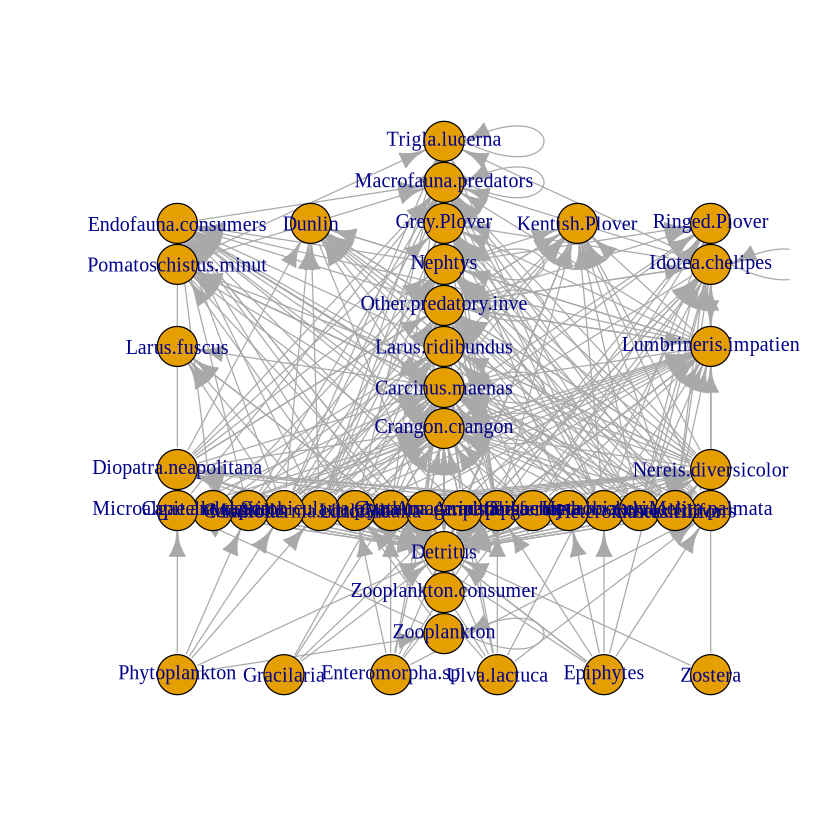

In [2]:
# Read the foodweb from the Mondego Estuary 
FW_Afilename<-"./Data/Mondego_adjacency.csv"
df <- read.csv(FW_Afilename, row.names = 1)
A <- as.matrix(df)
FW <- graph_from_adjacency_matrix(
  A,
  mode = "directed",   # or "undirected"
  weighted = TRUE,     # FALSE if binary
)
plot_as_flux(FW)

#### Bipartite networks from Incidence matrices

This type of networks are very frequent in ecology. 
While *igraph* does not have a dedicated bipartite graph class, the normal graph classes can be used to represent bipartite graphs. 
However, you have to keep track of which set each node belongs to, and make sure that there is no edge between nodes of the same set. 
The convention used in *igraph* is to use a node attribute named `type` with values TRUE or FALSE to identify the sets each node belongs to. 
This convention is not enforced in the code of *igraph* functions, it’s only a recommendation. Let's see how we can create a bipartite mutualistic network using *igraph* and reading from the $N_p x N_A$ Incidence matrix ($I$). 

*Again, note that the first row are the animal names and the first column the plant names.You should allways check that the structure matches what you expect*

[1] TRUE

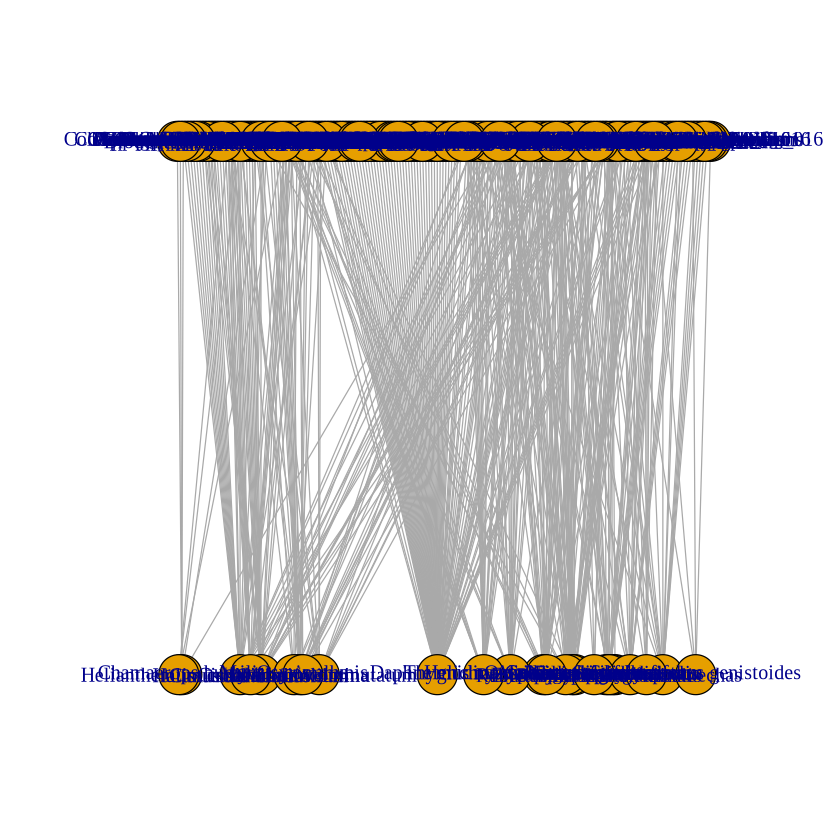

In [3]:
# Read the polination network from
B_Ifilename <- "./Data/Herrera_Donana_incidence.csv"
df <- read.csv(B_Ifilename, row.names = 1)
I <- as.matrix(df)
B <- graph_from_biadjacency_matrix(t(I))
is_bipartite(B)
plot(B, layout = layout_as_bipartite)

### Reading networks from Interaction lists

While the matrix form is the most common way to store information, is not the most efficient. When networks are large the matrix form stores a lot of 0s that are not relly needed. There is another format in which interactions can be stored, which is much more efficient for large networks: interaction lists. 

Interaction lists only contain the itneractions that exists in the network, and can also be stored in a dataframe where the first column represent the source node (from), and the second column the sink node (to), with an optional third column that contains information about the link, like for example the weigth or the sign of the interaction. 


#### Unipartite networks

Let's see how the itneraction list of the Mondego foodweb looks like

In [4]:
FW_Ifilename <-"./Data/
FW_Ilist <- read.csv(FW_IfilenamMondego_ilist.csv")
head(FW_Ilist)
FW2 <- graph_from_data_frame(FW_Ilist,directed = TRUE) #direction can be selected here, if undirected no arrows are shown
plot_as_flux(FW2)

ERROR: Error in parse(text = input): <text>:2:51: unexpected ')'
1: FW_Ifilename <-"./Data/
2: FW_Ilist <- read.csv(FW_IfilenamMondego_ilist.csv")
                                                     ^


#### Bipartite networks

It is becoming more frequent to find mutualistic networks in this format. The important point here is that not all nodes appear in the two columns, rather plants will be in column one, and animals in column two, for example. 

[1] TRUE

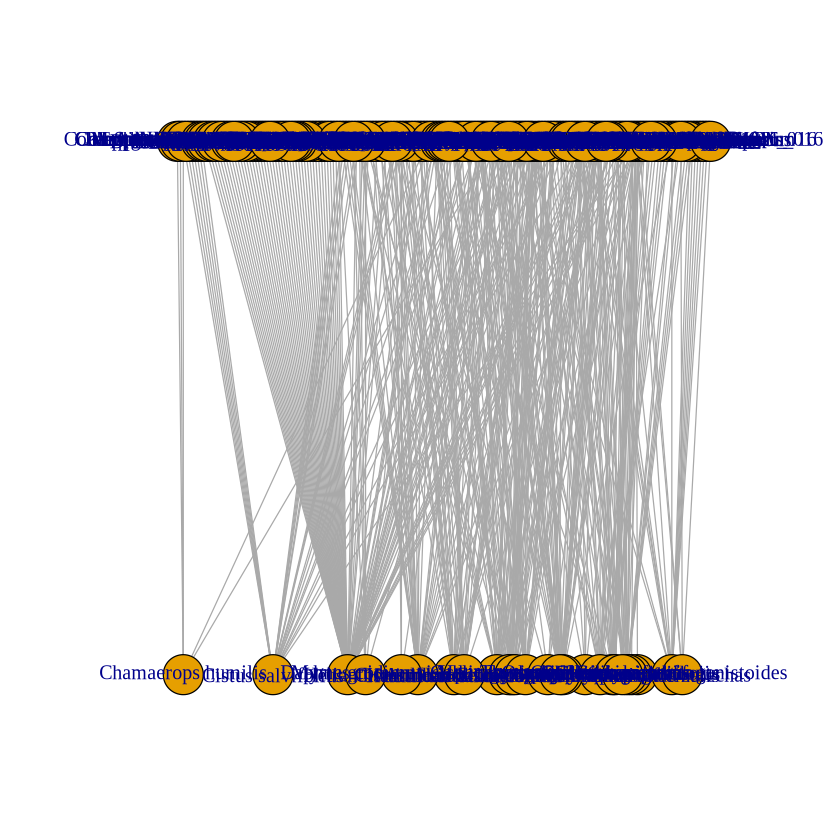

In [38]:
B_Ifilename<-"./Data/Herrera_Donana_ilist.csv"
B_Ilist <- read.csv(B_Ifilename)
B2 <- graph_from_data_frame(B_Ilist, directed = FALSE)
#however igraph does not directly understands this is a bipartite graph, so we need to specify the node sets
V(B2)$type <- V(B2)$name %in% B_Ilist$plant_sp #Planst as type==TRUE
is_bipartite(B2)
plot(B2, layout = layout_as_bipartite)

# Part 2 
Now let's continue with basic functions of igraph to access graph elements, and basic properties.
Here we will learn how to ask simple questions:

- Who's there? (Richness)
- How many interactions we have? (Link number, Conectance)

### Counting nodes and obtaining nodes in a graph:

We can get all the nodes(vertices) in a network using `V(g)`. We may use this if we want to iterate over the species, for example, or to know their names.

We can get the number of nodes and edges in a graph using the `vcount(g)`. This gives species richness

#### Unipartite networks 
In unipartite is easy, as we have only 1 type of node, usually. Lets explore the foodweb we read before

In [22]:
# let's obtain the number of nodes and links in the previous foodweb
my_nodes=V(FW)
N=vcount(FW)
print(sprintf("the network as %s nodes", N))
my_nodes


[1] "the network as 43 nodes"


+ 43/43 vertices, named, from 9ae8c93:
 [1] Phytoplankton        Enteromorpha.sp      Ulva.lactuca        
 [4] Zostera              Epiphytes            Gracilaria          
 [7] Zooplankton          Hydrobia.ulvae       Melita.palmata      
[10] Ampithoe.ferox       Gibulla              Littorina           
[13] Cyathura.carinata    Scrobicularia.plana  Cerastoderma.edule  
[16] Modiolus             Amage.adspersa       Capitella.capitata  
[19] Heteromastus.filifor Oligochaeta          Other.detrivors     
[22] Nephtys              Other.predatory.inve Idotea.chelipes     
[25] Sphaeroma.hookeri    Nereis.diversicolor  Carcinus.maenas     
[28] Crangon.crangon      Lumbrineris.impatien Diopatra.neapolitana
+ ... omitted several vertices

#### Bipartite networks 
In *igraph* by defect it returns all species:

In [23]:
my_nodes=V(B)
N=vcount(B)
cat(sprintf("the network as %s nodes \n #################", N))
my_nodes


the network as 205 nodes 
 #################

+ 205/205 vertices, named, from 6d21508:
  [1] Acmaeodera.sp1.M_PL_016          Acrobasis.porphyrella           
  [3] Agrotis.puta                     Amegilla.fasciata               
  [5] Amegilla.quadrifasciata          Ammophila.heydeni               
  [7] Andrena.assimilis                Andrena.bicolor                 
  [9] Andrena.bimaculata               Andrena.hispania                
 [11] Andrena.nigroaenea               Andrena.sp1.M_PL_016            
 [13] Andrena.squalida                 Anthaxia.dimidiata              
 [15] Anthaxia.parallela               Anthidiellum.strigatum          
 [17] Anthophora.acervorum             Anthophora.dispar               
 [19] Anthophora.sp1.M_PL_016          Anthrenus.sp1.M_PL_016          
+ ... omitted several vertices

In bipartite networks apart from total richness we may want the richness of each species set. For that we need to have information about the set each node belongs to, which usually is located in the attribute **type**

In [24]:
top_nodes <- V(B)$name[V(B)$type == FALSE] #animals
bottom_nodes <- V(B)$name[V(B)$type == TRUE] #plants
Na=length(top_nodes)
Np=length(bottom_nodes)
print(sprintf("the network as %s plant sp, and %s pol. sp.", Na,Np))


[1] "the network as 179 plant sp, and 26 pol. sp."


In [25]:
#I can know what attributes the node have with this
vertex_attr_names(B) 

[1] "type" "name"

### Counting edges and obtaining edges in a graph

We can get all the links (or edges) in a graph with  the function `E(g)`. This may be important to check if a particular interaction exists. 

We can get the number of links in a graph with  the `ecount(g)` function. This allow sus to compute average degree and connectance, i.e. how dense are the conections in my graph.

Lets see with out previous examples

#### Unipartite networks: foodweb

In [26]:
#unipartite :foodweb 

L=ecount(FW)
N=vcount(FW)
L
cat(sprintf("The average number of connections of each species is k=%s \n",L/N))
cat(sprintf("Network connectance is c=%s",L/(N*N))) # classic one

#it has a function 
edge_density(FW, loops = TRUE)   # L / S^2  -> la conectancia clásica de Martinez
edge_density(FW)                 # L / (S(S-1)), sin contar autoenlaces

[1] 348

The average number of connections of each species is k=8.09302325581395 
Network connectance is c=0.188209843158464

[1] 0.1882098

[1] 0.192691

#### Bipartite network: mutualistic

In this case, we may want to know the average number of conections for species of each set, apart from the average conection in general. 

In [27]:
#bipartite mutualistic 
L=ecount(B)
L
cat(sprintf("Network connectance is c=%s\n",L/(Na*Np))) # it means we have 412 active links from all the possible NaxNp

cat(sprintf("The average number of connections of each plant species is k=%s \n",L/Np))

cat(sprintf("The average number of connections of each animal species is k=%s \n",L/Na))



[1] 412

Network connectance is c=0.0885259991405243
The average number of connections of each plant species is k=15.8461538461538 
The average number of connections of each animal species is k=2.30167597765363 


### Counting nodes and obtaining nodes in a matrix format
In addition, if you are workingwith the adjacency or incidence matrix you can retrieve species richness just by counting the number of rows or columns

#### Unipartite networks
You just need to count the number of rows of columns of the adjacency matrix. Let's try with the matrix of the foodweb

In [28]:
N<-nrow(A)
cat(sprintf("There are %s species in the foodweb",N))

There are 43 species in the foodweb

#### Bipartite networks
In bipartite networks, the number of plant species is usually the numbre of rows, and the number of animal species the numbre of columns. Let's try with the incidence matrix of the mutualistic network.

In [29]:
Na<-ncol(I)
Np<-nrow(I)
print(sprintf("the network as %s plant sp, and %s pol. sp.", Np,Na))

[1] "the network as 26 plant sp, and 179 pol. sp."


### Counting edges in a matrix format

In the case of a matrix, this is just a matter of filter what elements are differnt from 0 and divide them among the number of species

#### Unipartite networks

In the foodwebs is a matter of obtaining how non zero entries we have in the adjacency matrix, and then divide them among the species:

In [5]:
L <- sum(A>0)
L
N<-nrow(A)
cat(sprintf("The average number of connections of each species is k=%s \n",L/N))
cat(sprintf("Network connectance is c=%s",L/(N*N))) # classic one

[1] 348

The average number of connections of each species is k=8.09302325581395 
Network connectance is c=0.188209843158464

#### Bipartite networks

In mutualistic networks, we will use the **Incidence** matrix ($N_a x N_p$), and we can check what is the average number of non-zero elements per row (average conections of plants) and per column (average conection of animals)

In [6]:
L <- sum(I>0)
L
Na<-ncol(I)
Np<-nrow(I)
Na
Np

cat(sprintf("Network connectance is c=%s\n",L/(Na*Np))) # it means we have 412 active links from all the possible NaxNp

cat(sprintf("The average number of connections of each plant species is k=%s \n",L/Np))
cat(sprintf("The average number of connections of each animal species is k=%s \n",L/Na))

[1] 412

[1] 179

[1] 26

Network connectance is c=0.0885259991405243


The average number of connections of each plant species is k=15.8461538461538 
The average number of connections of each animal species is k=2.30167597765363 


alternatively, **in bipartite networks only** you can also use the package bipartite. However, you have to be very careful, this retrieves the average connection of ALL nodes:

In [7]:
networklevel(I, index = c("connectance", "links per species", "number of species"))

connectance    links per species number.of.species.HL 
            0.088526             2.009756           179.000000 
number.of.species.LL 
           26.000000

if you want to get the average connection of pollinator or plants, you need to look at the group level metrics:

In [8]:
grouplevel(I, index = "mean number of links",weighted = FALSE)

mean.number.of.links.HL mean.number.of.links.LL 
               2.301676               15.846154

### Degree of nodes

The most basic structural properties of a network are the number of nodes (**N**) and the number of links (**L**). 
However, how these links are distributed among the nodes (**$K_i$**) has deep implications for other network properties (it is not the same to have all nodes with similar degree, or having a very heterogeneous dostribution). 

The degree distribution will play a very important role determining other structural metrics in the networks.
We can see the **degree distribution** of a network by doing a histogram of the degree series. This will tell us how many nodes with a given number of neighbours are in the network.


*igraph* and *bipartite* both have functions to get the degree sequence and to get the degree distribution (i.e. how many nodes with a given degree are in the network) `degree_distribution(G)`.

#### Unipartite networks: foodweb

For unipartite networks we use *igraph*, which provides `degree(G)` to get the degree of each node and `degree_distribution(G)` to get the degree distribution, i.e. the fraction of nodes with each degree value. Since food webs are directed networks, each node has an in-degree (the number of links pointing to it) and an out-degree (the number of links leaving it), and we can study them separately. Let's see it applied to ou foodweb

Phytoplankton      Enteromorpha.sp         Ulva.lactuca 
                   6                    8                    8 
             Zostera            Epiphytes           Gracilaria 
                   2                    8                    4 
         Zooplankton       Hydrobia.ulvae       Melita.palmata 
                  11                   17                   17 
      Ampithoe.ferox              Gibulla            Littorina 
                  19                   12                   12 
   Cyathura.carinata  Scrobicularia.plana   Cerastoderma.edule 
                   7                   19                   18 
            Modiolus       Amage.adspersa   Capitella.capitata 
                   9                    7                    8 
Heteromastus.filifor          Oligochaeta      Other.detrivors 
                  15                   10                   16 
             Nephtys Other.predatory.inve      Idotea.chelipes 
                  26                   33                   19 
   Sphaeroma.hookeri  Nereis.diversicolor      Carcinus.maenas 
                   5                   24                   39 
     Crangon.crangon Lumbrineris.impatien Diopatra.neapolitana 
                  37                   27                   17 
Microalgae.and.detri Zooplankton.consumer  Endofauna.consumers 
                   8                    7                   23 
Macrofauna.predators       Trigla.lucerna Pomatoschistus.minut 
                  29                   18                   11 
    Larus.ridibundus         Larus.fuscus       Kentish.Plover 
                  10                    5                   15 
       Ringed.Plover          Grey.Plover               Dunlin 
                  13                   14                   14 
            Detritus 
                  69

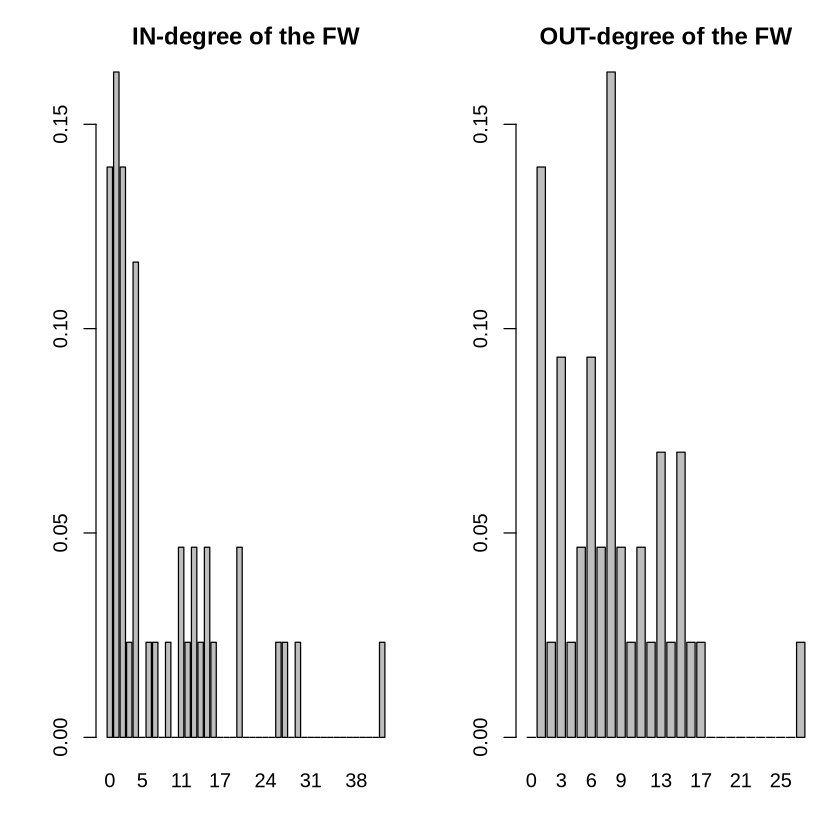

In [9]:
k <- igraph::degree(FW)
k

#obtain the degree distributions
Pin=degree_distribution(FW, mode="in")
Pout=degree_distribution(FW, mode="out")


op <- par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))  # 1 row, 2 columns
barplot(degree_distribution(FW,mode="in"), names.arg=as.character(0:max(igraph::degree(FW,mode="in"))),  main='IN-degree of the FW')
barplot(degree_distribution(FW,mode="out"), names.arg=as.character(0:max(igraph::degree(FW,mode="out"))),  main='OUT-degree of the FW')
par(op)  # restore old graphics settings

#### Bipartite networks: mutualism

For bipartite networks we use the *bipartite* package, which works directly on the incidence matrix. `specieslevel(I, index = "degree")` returns the degree of each species, separately for the lower level (rows, here plants) and the higher level (columns, here pollinators), and `degreedistr(I)` plots the cumulative degree distribution of each level. Because the two sets of nodes play different ecological roles, we always study their degrees separately. Note that `grouplevel(I, index = "mean number of links")` returns a weighted mean by default; to get the plain average degree of each level, add `weighted = FALSE`:

In [10]:
sl <- specieslevel(I, index = "degree") #get th degree of all nodes
k_plantas <- sl$`lower level`$degree
k_animals <- sl$`higher level`$degree

k_plantas
k_animals


[1] 20 16 23  5 28 26  1 86 13 12 18  3 19 16  5  6  5 17  1 21 19 15  4 22  7
[26]  4

[1]  2  1  1  4  2  1  1  1  1  4  2  1  2  2  1  2  1  2  1  9 14  2  1  1  1
 [26]  1  2  1  2  1  3  1  1  1  7  4  3  2  2  1  2  1  1  1  1  1  4  4  2  2
 [51]  1  3  4  1  2  3  2  1  2  1  4  1  2  1 17  7  5  1  1  1  3  1  4  3  1
 [76]  3 10  3  1  1  1  1  2  1  1  1  1  6  1  1  2  1  1  1  1  1  1  3  3  1
[101]  1  1  4  1  8  7  1  9  7  6  1  7  2  2  1  2  5  2  1  2  3  1  1  1  3
[126]  3  1  1  3  3  1  1  5  5  1  1  1  2  1  1  1  1  1  1  1  1  2  1  1 11
[151]  1  2  3  1  2  1  1  1  1  1  1  1  5  1  1  1  2  4  1  1  1  2  2  2  1
[176]  1  1  7  1

you can even get the degree distribution and see what type of function better is a better fit (lower aic)

,Estimate,Std. Error,Pr(>|t|),R2,AIC
exponential,NA,NA,NA,NA,NA
power law,0.40593306,0.05682466,1.181815e-06,0.8607667,-13.34855
truncated power law,-0.09420376,0.07383114,2.191369e-01,0.9728122,-43.43417
,Estimate,Std. Error,Pr(>|t|),R2,AIC
exponential,0.6390216,0.04289371,1.224679e-08,0.9948334,-45.78959
power law,1.3245628,0.04273343,4.672958e-12,0.9975734,-57.47336
truncated power law,0.9200405,0.03051514,3.770559e-11,0.9998725,-97.00585


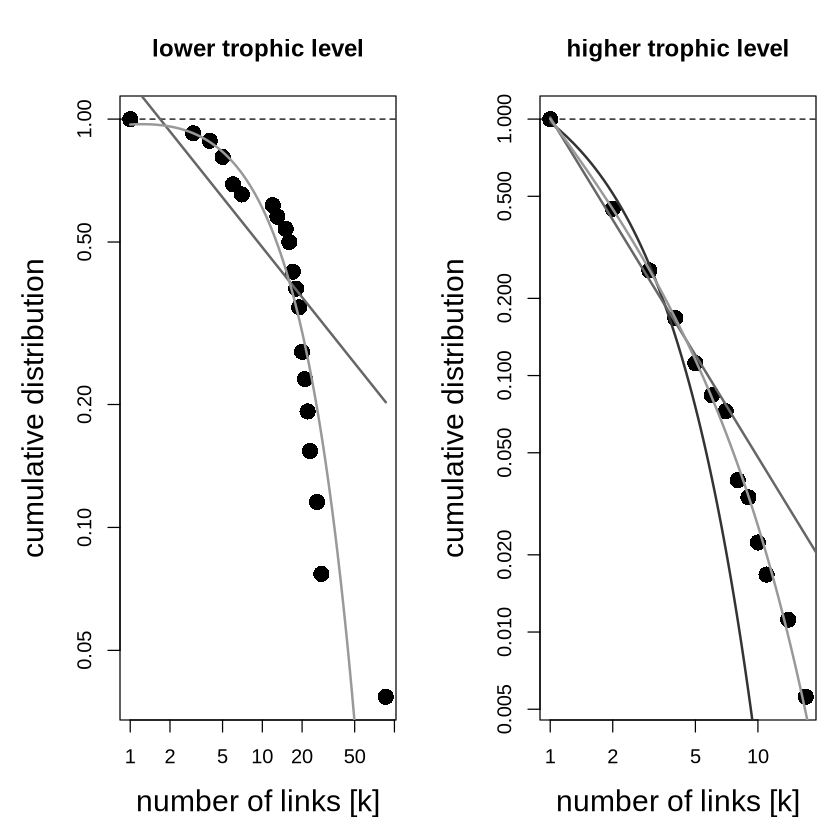

In [11]:
degreedistr(I)

# Part 3 

Ok so looking at those figures, it shows that there are differnt tyes of nodes, at least if we look at their number of neighbours.

Let's take a look at these two networks, what is the bigger difference?

<img src="images/figure7.png" width="900">


- Local structure (Centrality metrics)
- Global or community structure (modularity, nestedness)

## 3A : Local structure



### Degree Centrality
A node has a high degree centrality if it has many neighbours, a concept that is simple and appealing.
Hpwever, it leaves us with a slight point of dissatisfaction: it is difficult to compare graphs of different sizes.
Is a node more important solely because it has more neighbors?
What if it were situated in an extremely large graph? Would we not expect it to have more neighbors?

As such, we need a normalization factor.
One reasonable one, in fact, is _the number of nodes that a given node could **possibly** be connected to._
By taking the ratio of the number of neighbors a node has to the number of neighbors it could possibly have,
we get the **degree centrality** metric.



#### Unipartite networks

Formally defined, the degree centrality of a node (let's call it $d$) is the number of neighbors that a node has (let's call it $k$, its degree)
divided by the number of neighbors it could _possibly_ have (let's call it $N$, all nodes):

$$d = \frac{k}{N}$$

*igraph* does NOT provide an inbuilt function for this, so the normalization must be done by hand like this:

Degree cenrtality 

`igraph::degree(g) / (igraph::vcount(g) - 1)`

Directed versions:

`igraph::degree(g, mode="in")  / (igraph::vcount(g) - 1)`
`igraph::degree(g, mode="out") / (igraph::vcount(g) - 1)`

In [12]:
d <- igraph::degree(FW,mode="in")/vcount(FW-1)


#### Bipartite networks
When we are working with bipartite networks, we need to take into consideration that we have two different sets of species, and that they can only connect to species in the other set! 

In the bipartite case, the maximum possible degree of a node in a bipartite node set is the number of nodes in the opposite node set. The degree centrality for a node $u$ in the bipartite set $U$ with $n$ nodes that is connected to nodes in the bipartite set $V$ with $m$ nodes is
$d_u=\frac{k_u}{m}$, for $u\in U$, and for a node $v$ nodes in set $V$ is $d_v=\frac{k_v}{n}$, for $v\in V$, where $k_v$ is the degree of node v.

The *bipartite* package computes this directly with `specieslevel(I, index = "normalised degree")`, which returns, for each plant, its degree divided by the number of pollinators, and for each pollinator, its degree divided by the number of plants. From the incidence matrix we can also get it as `rowSums(I > 0) / ncol(I)` for plants and `colSums(I > 0) / nrow(I)` for pollinators. 
A value of 1 means that a species interacts with every species of the other level.

In [13]:
sl <- specieslevel(I, index = "normalised degree")
dp <- sl$`lower level`$normalised.degree    # plantas: degree / n.º de polinizadores
da <- sl$`higher level`$normalised.degree   # polinizadores: degree / n.º de planta

> Note: degree centrality is usefull to determine how "central" a node is **across** different networks, since **it does not make sense to compare the raw number of neighbours across networks with different size**!!

### Common centrality metrics

As we have seen before, one can be "important" in different ways. 
*igraph* provides the most common metrics of node centrality
- `degree(g)`                        # Degree centrality
- `closeness(g)`                     # Closeness centrality
- `betweenness(g)`                   # Betweenness centrality
- `V(FW)$kcore <- igraph::coreness(FW)`   # Kcore of node
- `eigen_centrality(g)$vector`       # Eigenvector centrality
- `page_rank(FW)$vector`                  # Page rank




#### Unipartite

The importances of the nodes does not always necesarily coincides. Let's see it in our foodweb


In [14]:
#compute several metrics of node centrality, and store them in the graph nodes
V(FW)$degree <- igraph::degree(FW)                        # Degree centrality
V(FW)$eig <- igraph::eigen_centrality(FW)$vector          # Eigenvector centrality
V(FW)$closeness <- igraph::closeness(FW)                  # Closeness centrality
V(FW)$betweenness <- igraph::betweenness(FW)              # Vertex betweenness centrality
V(FW)$pr <- igraph::page_rank(FW)$vector                  # Page rank
V(FW)$kcore <- igraph::coreness(FW)                       # Kcore 

#createa a datafram of centrlity metrics 
centrality_df <- data.frame(row.names   = V(FW)$name,
                         degree      = V(FW)$degree,
                         closeness   = V(FW)$closeness,
                         betweenness = V(FW)$betweenness,
                         eigenvector = V(FW)$eig,
                         pr = V(FW)$pr,
                         kcore= V(FW)$kcore
                         )


It is possible to color the nodes according to a given property, like this

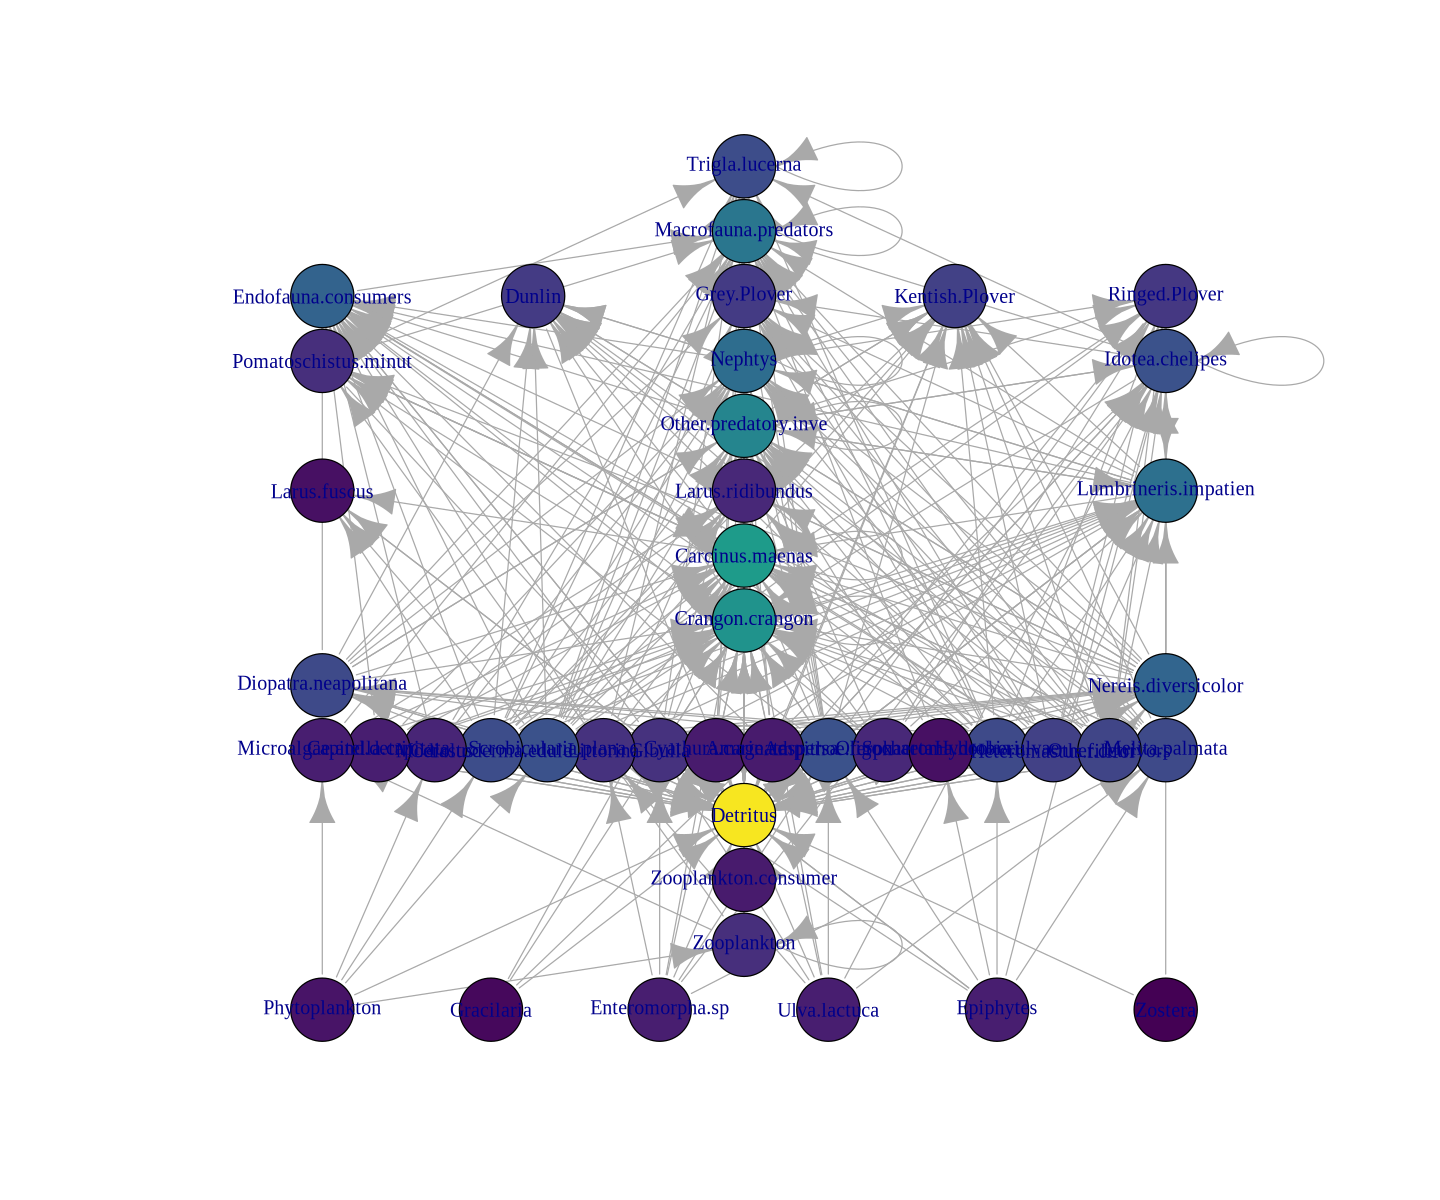

In [15]:
metric <- V(FW)$degree   # <-- choose metric here betweenness, closeness, eig, pr
cols <- metric_to_color(metric)
options(repr.plot.width = 12, repr.plot.height = 10)
plot_as_flux(FW, vertex.color = cols)

In [128]:
cor(centrality_df, method="spearman") 

,degree,closeness,betweenness,eigenvector,pr,kcore
degree,1.000000000,-0.001890433,0.5392121,0.173163635,0.7196941,0.913381417
closeness,-0.001890433,1.000000000,-0.4760812,0.322108124,0.3241223,0.069580856
betweenness,0.539212081,-0.476081195,1.0000000,-0.401166077,0.1010023,0.477089147
eigenvector,0.173163635,0.322108124,-0.4011661,1.000000000,0.5172197,-0.007977947
pr,0.719694110,0.324122311,0.1010023,0.517219672,1.0000000,0.582914125
kcore,0.913381417,0.069580856,0.4770891,-0.007977947,0.5829141,1.000000000


#### Bipartite networks

Bipartite does not have all of those metrics, but it has some:

In [16]:
# Centralidades por especie
sl <- specieslevel(I, index = c("normalised degree", "betweenness", "closeness"))

centrality_p_df<- sl$`lower level`    # plantas
centrality_a_df<-sl$`higher level`   # polinizadores

(centrality_p_df)

,normalised.degree,betweenness,weighted.betweenness,closeness,weighted.closeness
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Armeria velutina,0.111731844,0.033630952,0.025328330,0.03975265,0.03353717
Asparagus aphyllus,0.089385475,0.039601503,0.000000000,0.04063604,0.03341225
Calluna vulgaris,0.128491620,0.076533321,0.052532833,0.04240283,0.03793391
Chamaerops humilis,0.027932961,0.000000000,0.000000000,0.02915194,0.01479145
Cistus libanotis,0.156424581,0.141017448,0.102251407,0.04416961,0.03587104
Cistus salvifolius,0.145251397,0.091811099,0.121951220,0.04328622,0.03446205
Cytisus grandiflorus,0.005586592,0.000000000,0.000000000,0.03356890,0.01117313
Daphne gnidium,0.480446927,0.049621344,0.481238274,0.04063604,0.04173114
Erica ciliaris,0.072625698,0.032539683,0.086303940,0.03798587,0.03233063


## 3B: Community structure

These are structures that describe the full network (i.e. the full community) and hence we only have one index per network. The most common metrics are modularity and nestedness

### Modularity
At a high level, network community detection consists of finding a partition that achieves good separation between the groups of nodes. 
Before we get into how to find good partitions of a graph, we need an objective -- a way to measure how good the partition is. Modularity is one such objective function.

The modularity of a graph partition compares the number of intra-group edges with a random baseline. Higher modularity scores correspond to a higher proportion of intra-group edges, therefore fewer inter-group edges and better separation of groups.

For weighted undirected networks, we have
\begin{equation}
    Q_w=\frac{1}{W}\sum_C \left(W_C-\frac{s_C^2}{4W}\right),
\end{equation}
where 
* $W$ is the total weight of the links of the network,
* $W_C$ the total weight of the internal links of cluster $C$, and
* $s_C$ the total strength of the nodes of $C$.

The total weight $W$ is half the total strength for the same reason that the number of edges $L$ is half the total degree. While this formula may look a bit complicated, it's straightforward to write code to compute the sum, but still *igraph* and *bipartite* provides a modularity function that is more efficient than one I can write.

#### Unipartite networks - Foodweb

Remember that the trophic netwokr is directed. The most common algorithm (louvain) uses only undirected networks. If we want to take direction into cosideration, one has tu use infomap. 

In [131]:
FW_bin <- igraph::delete_edge_attr(FW, "weight")
#communities by infomap
Com_infomap <- igraph::cluster_infomap(FW_bin)
Q_infomap  <- igraph::modularity(Com_infomap)

#communities by louvain
FW_und <- igraph::as_undirected(FW_bin, mode = "collapse")
Com_louvain<-cluster_louvain(FW_und)
Q_louvain <- igraph::modularity(Com_louvain)

print(Q_infomap)
print(Q_louvain) 

[1] 0
[1] 0.1614315


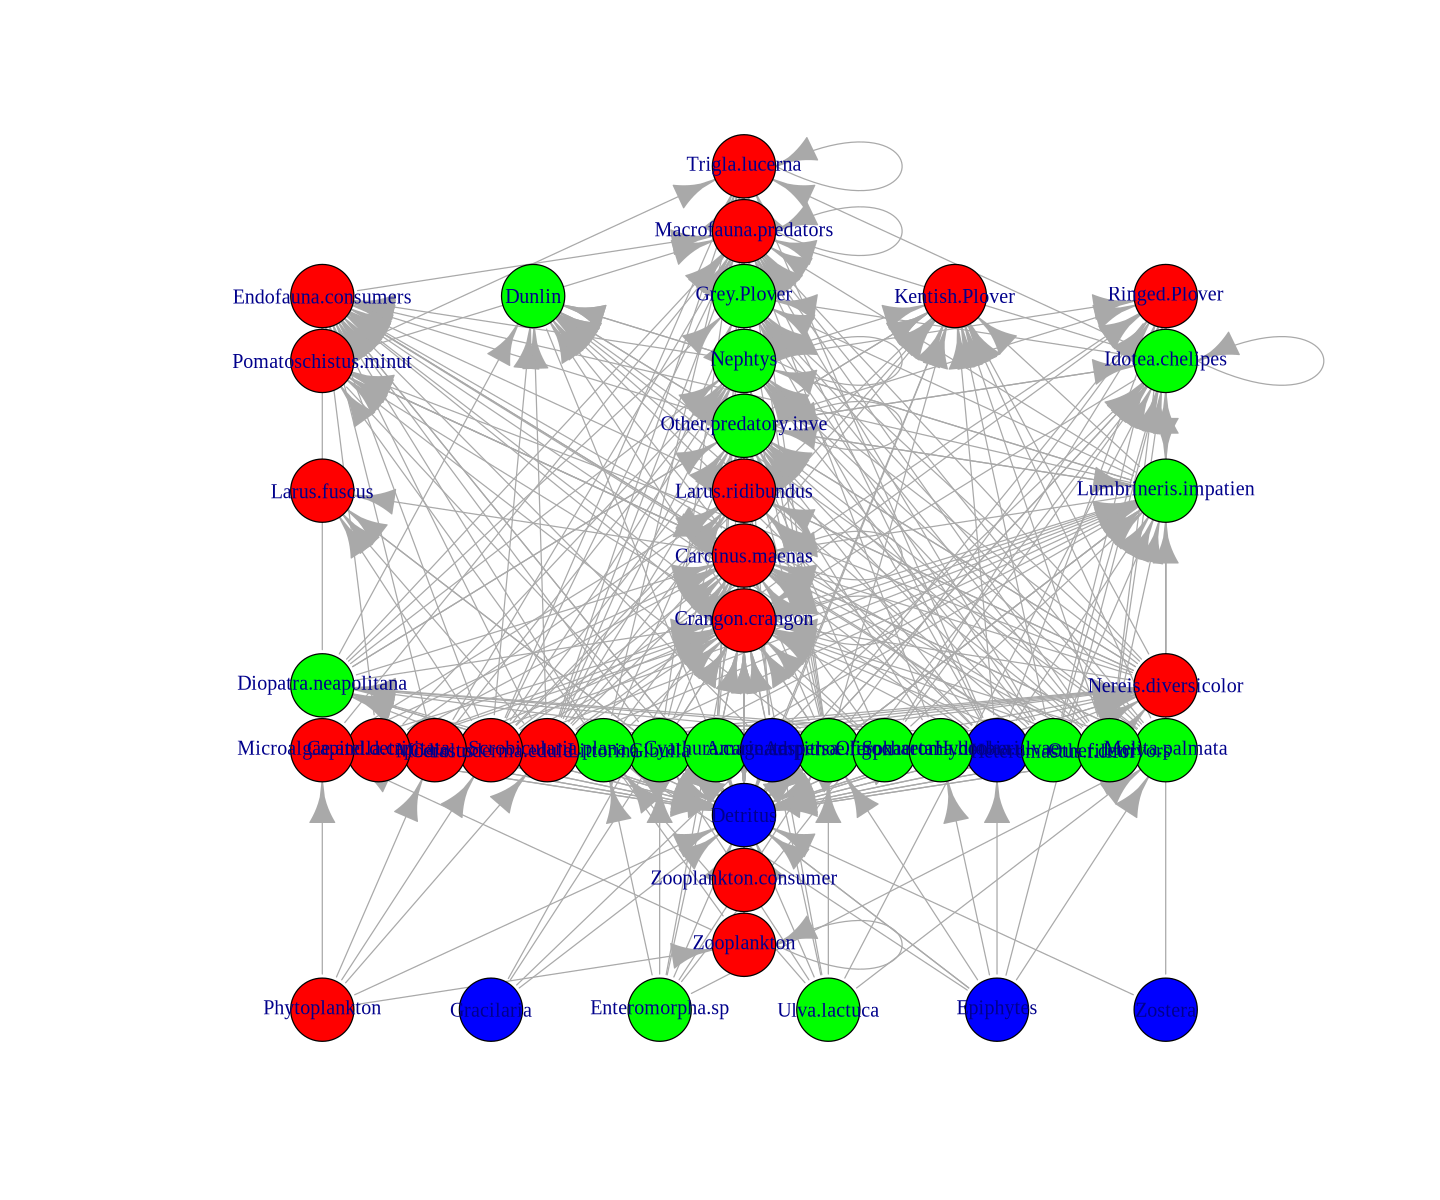

In [19]:
memb <- igraph::membership(Com_infomap)  
memb <- igraph::membership(Com_louvain)   # o mod_infomap
cols <- rainbow(max(memb))[memb]
plot_as_flux(FW, vertex.color = cols)

#### Bipartite networks

For bipartite networks we use  the *bipartite* package. Here modularity takes into account that there are two different guilds.

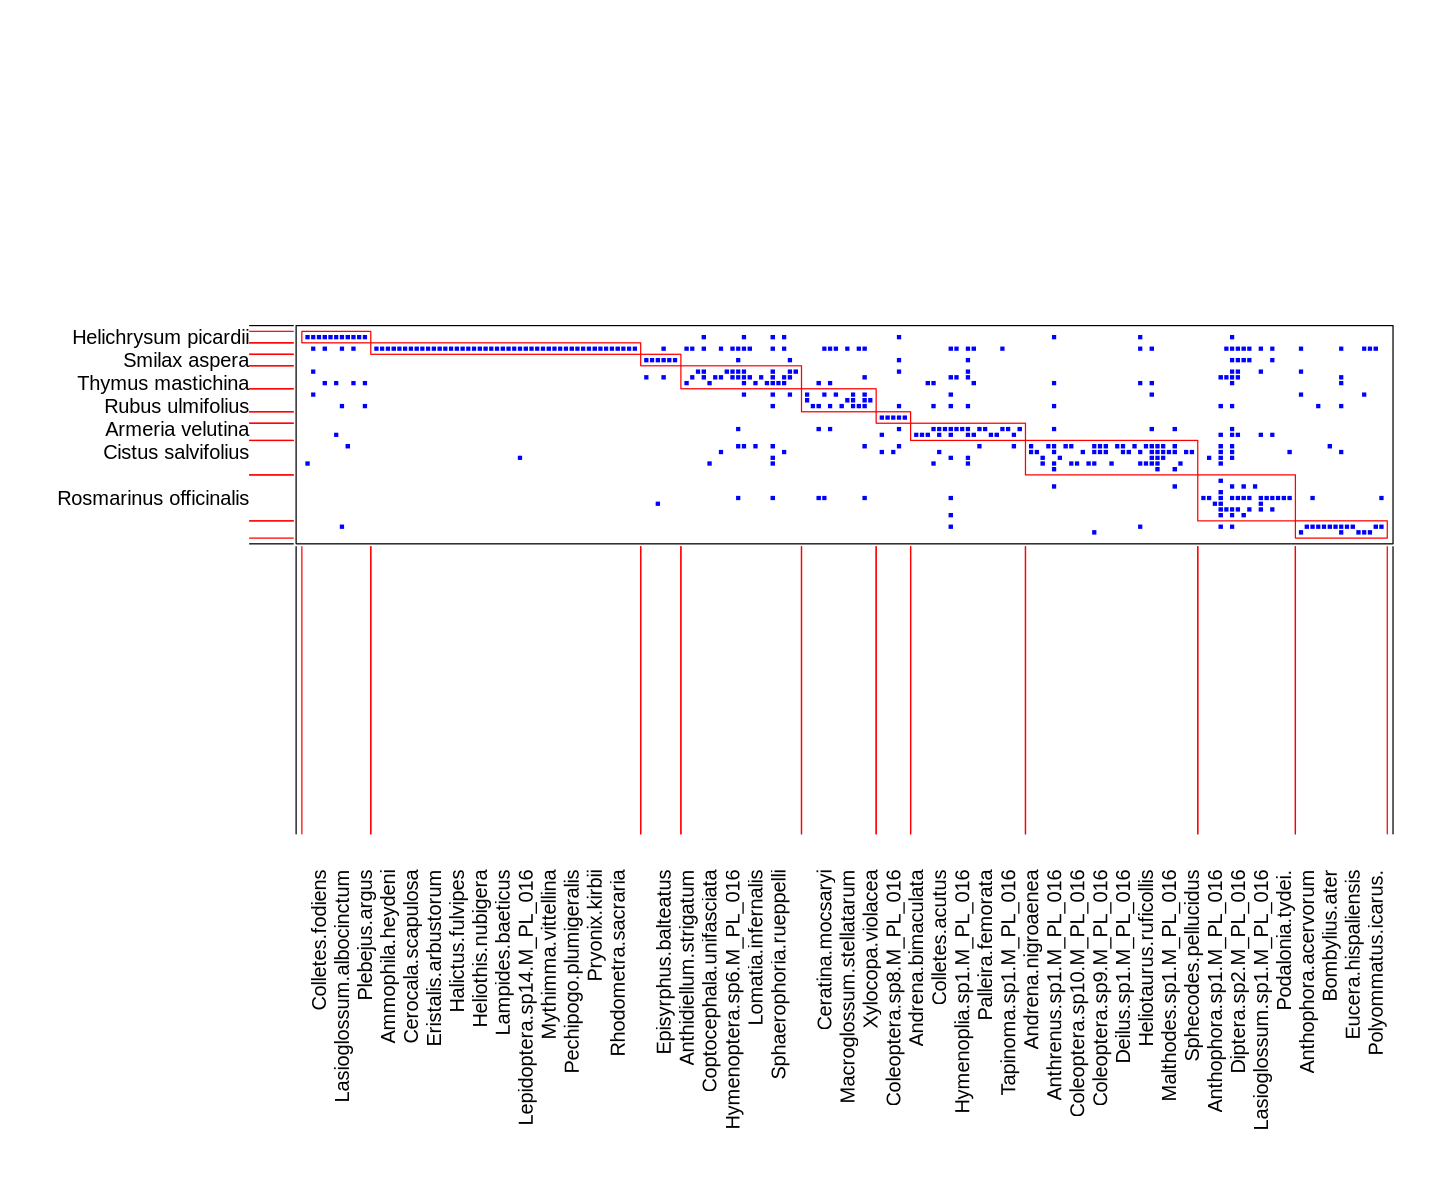

In [42]:
mod <- bipartite::computeModules(I)   # finds bipartite modules
plotModuleWeb(mod)  

We can retrieve the information of what node belong to each group, and the plot them in different colors

[1] 0

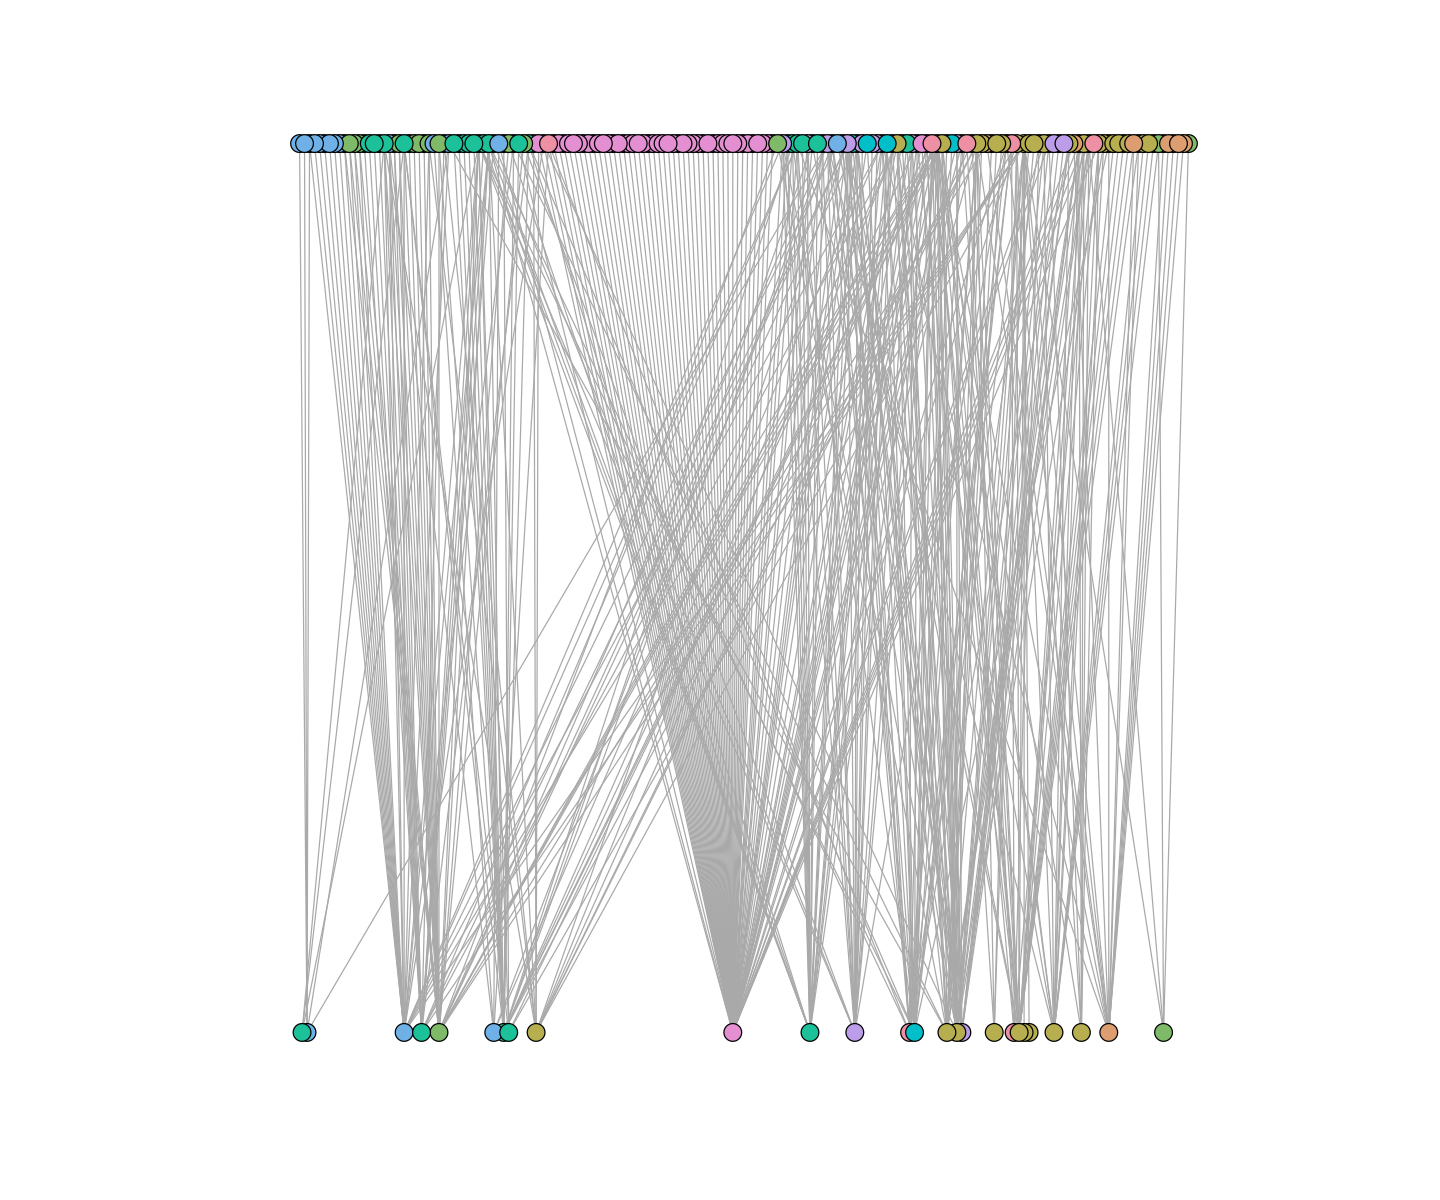

In [28]:
info <- bipartite::listModuleInformation(mod)[[2]]

memb <- setNames(rep(NA, vcount(B)), V(B)$name) #from list of groups to list of nodes
for (i in seq_along(info)) {
  memb[unlist(info[[i]])] <- i
}

sum(is.na(memb))   # debería ser 0
cols <- hcl.colors(max(memb), "Set 2")[memb]
plot(B, layout = layout_as_bipartite(B), vertex.color = cols,
     vertex.label = NA, vertex.size = 4)

### Nestedness

In this case we are only going to focus on bipartite networks, as nestedness in unipartite can be computed, but is not generally studied

The level of nestedness of the mutualistic matrix is usually estimated by means of appropriate software. However, Bastolla et al.  introduced an explicit definition of nestedness that makes the calculation more straightforward and had the advantage of being related to the form of the matrix of interactions. 

$$
\eta_{B}=\frac{\sum_{i<j}\hat{n}_{ij}}{\sum_{i<j}\min(k_{i},k_{j})},
$$
Here min(, ) refers to the smaller of the two values and , and the number of shared symbiotic partners,
$\hat{n}_{ij}=\sum_{l}\hat{a}_{il}\hat{a}_{lj}=(\hat{a}^{2})_{ij}$
This nestedness index ranges from zero to one, and is highly correlated with previous measures of nestedness.
These analytic version is however not implemented in bipartite, so we will focuss on NODF, whih is the most popular.

One can compute the nestedness of a bipartite network for example using NODF (unweighted version) or WNODF (weighted verison)



[1] 21.97691

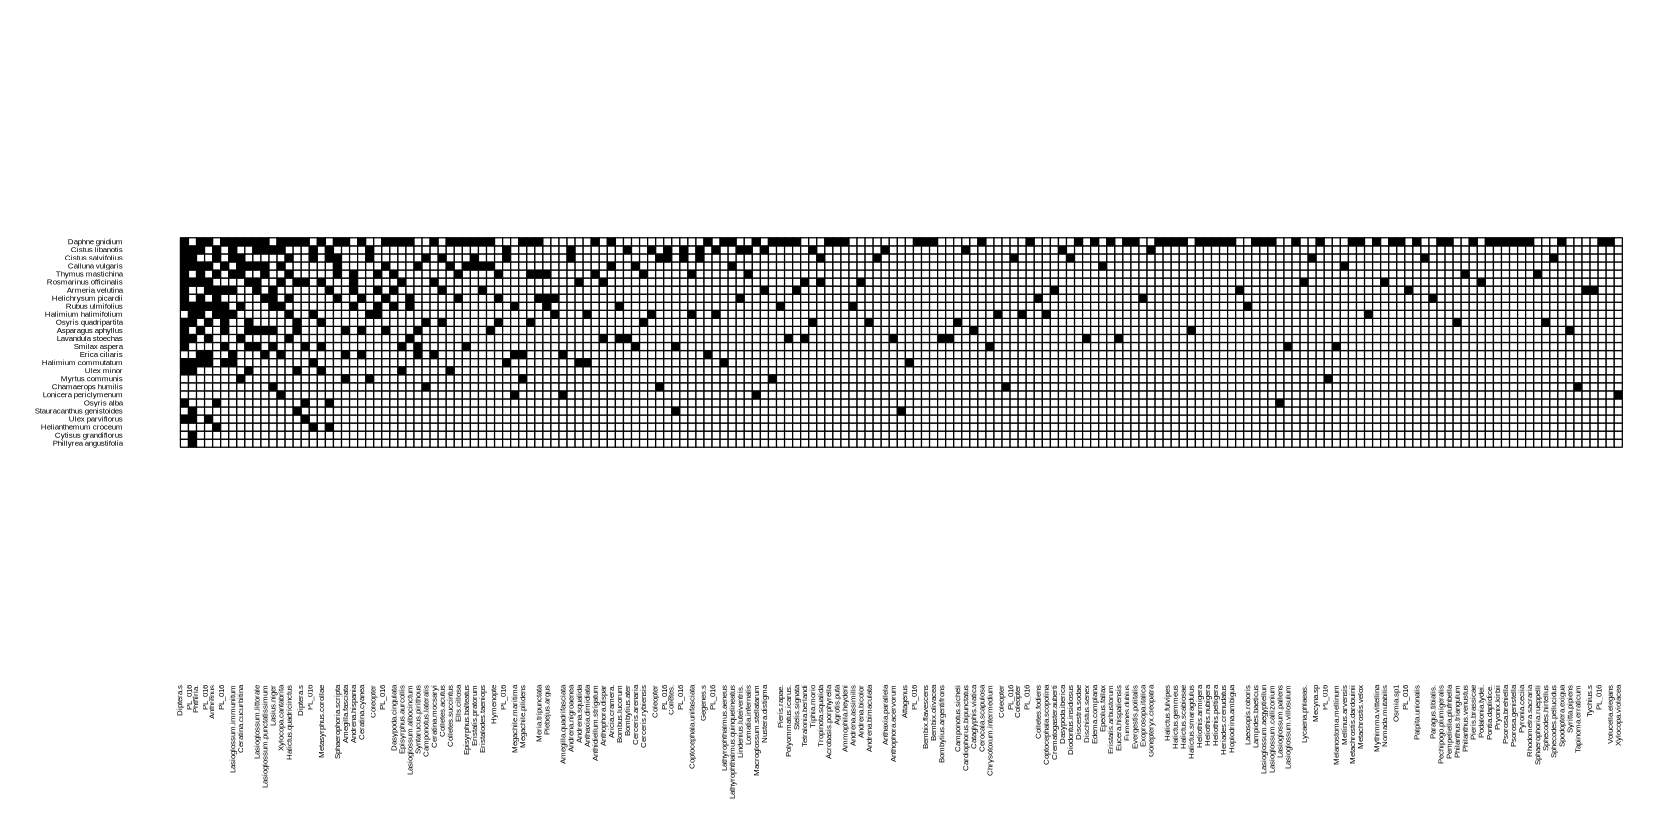

In [109]:
NODF<-bipartite::nested(I, method = "NODF2")          # binaria
visweb(I, type = "nested",labsize = 4)
as.numeric(NODF)

# Part 4

Here we will learn about the importance of null models and statistical significance

## 4A Null models:
- Random networks (constant N, L)
- Configuration model (constant row/col sum)

### Unipartite networks

For unipartite networks we will use *igraph* libraries

#### Random networks

To generate random networks (Erdos Reny graphs) that keep fixed the number of species $N$ and the number of links $L$ que can use the *igrpah* function `sample_gnm()`

In [73]:
N<-vcount(FW)
L<-ecount(FW)
FW_rand1 <- igraph::sample_gnm(N, L, directed = TRUE, loops = TRUE)


we can see if they look similar, for example by looking at the degree distribution

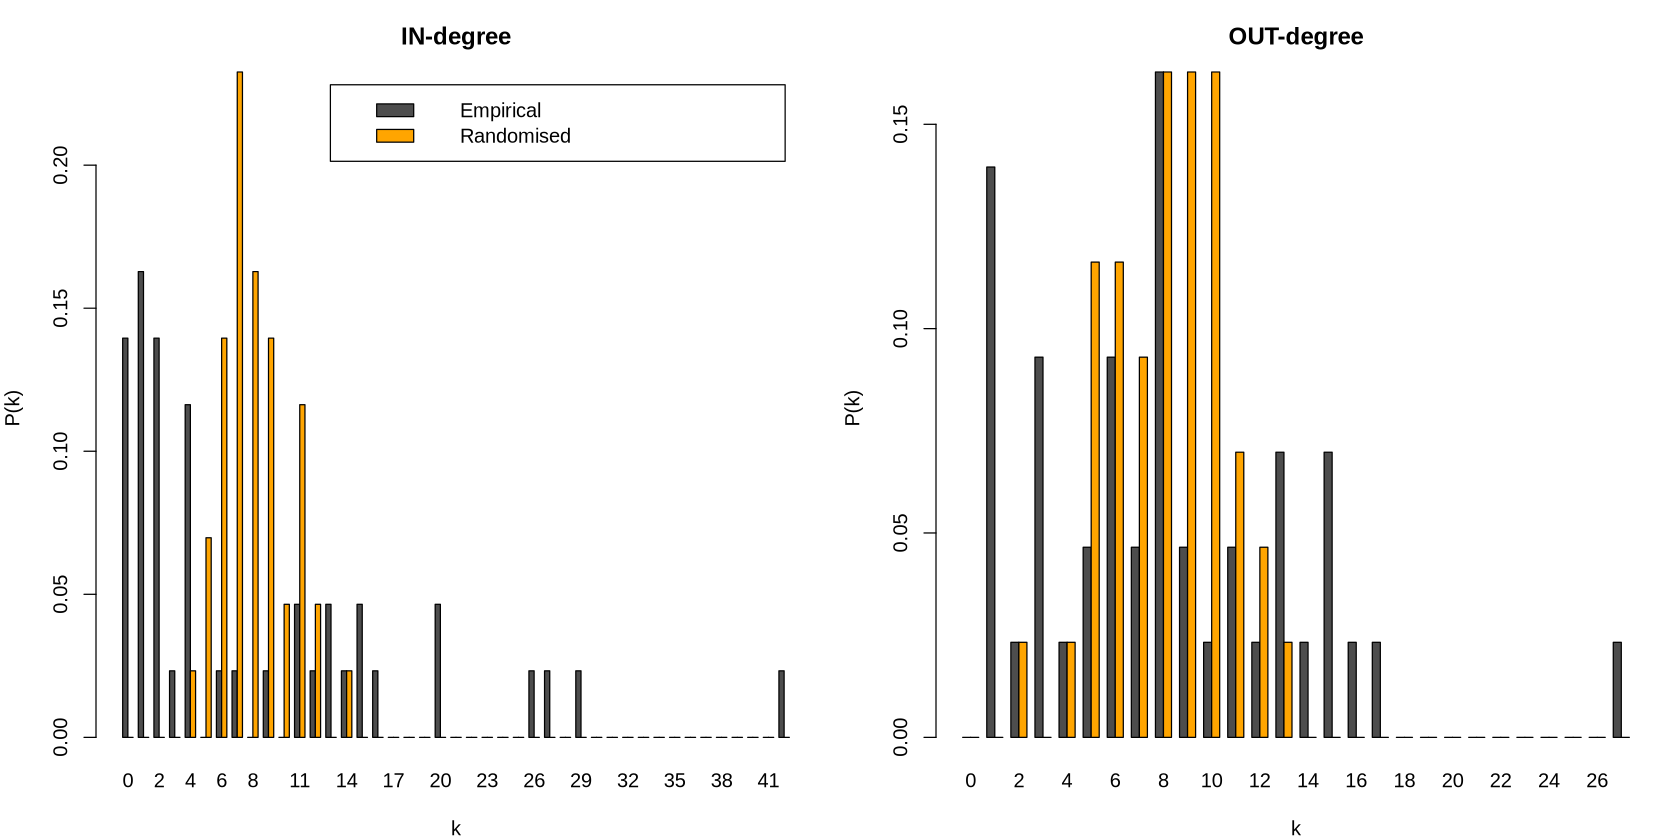

In [74]:
#obtain the degree distributions
op <- par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
cols <- c("grey30", "orange")

barplot(dd_pair(FW, FW_rand1, "in"), beside = TRUE, col = cols,
        main = "IN-degree", xlab = "k", ylab = "P(k)",
        legend.text = c("Empirical", "Randomised"))
barplot(dd_pair(FW, FW_rand1, "out"), beside = TRUE, col = cols,
        main = "OUT-degree", xlab = "k", ylab = "P(k)")

par(op)

Or the flux trought he network

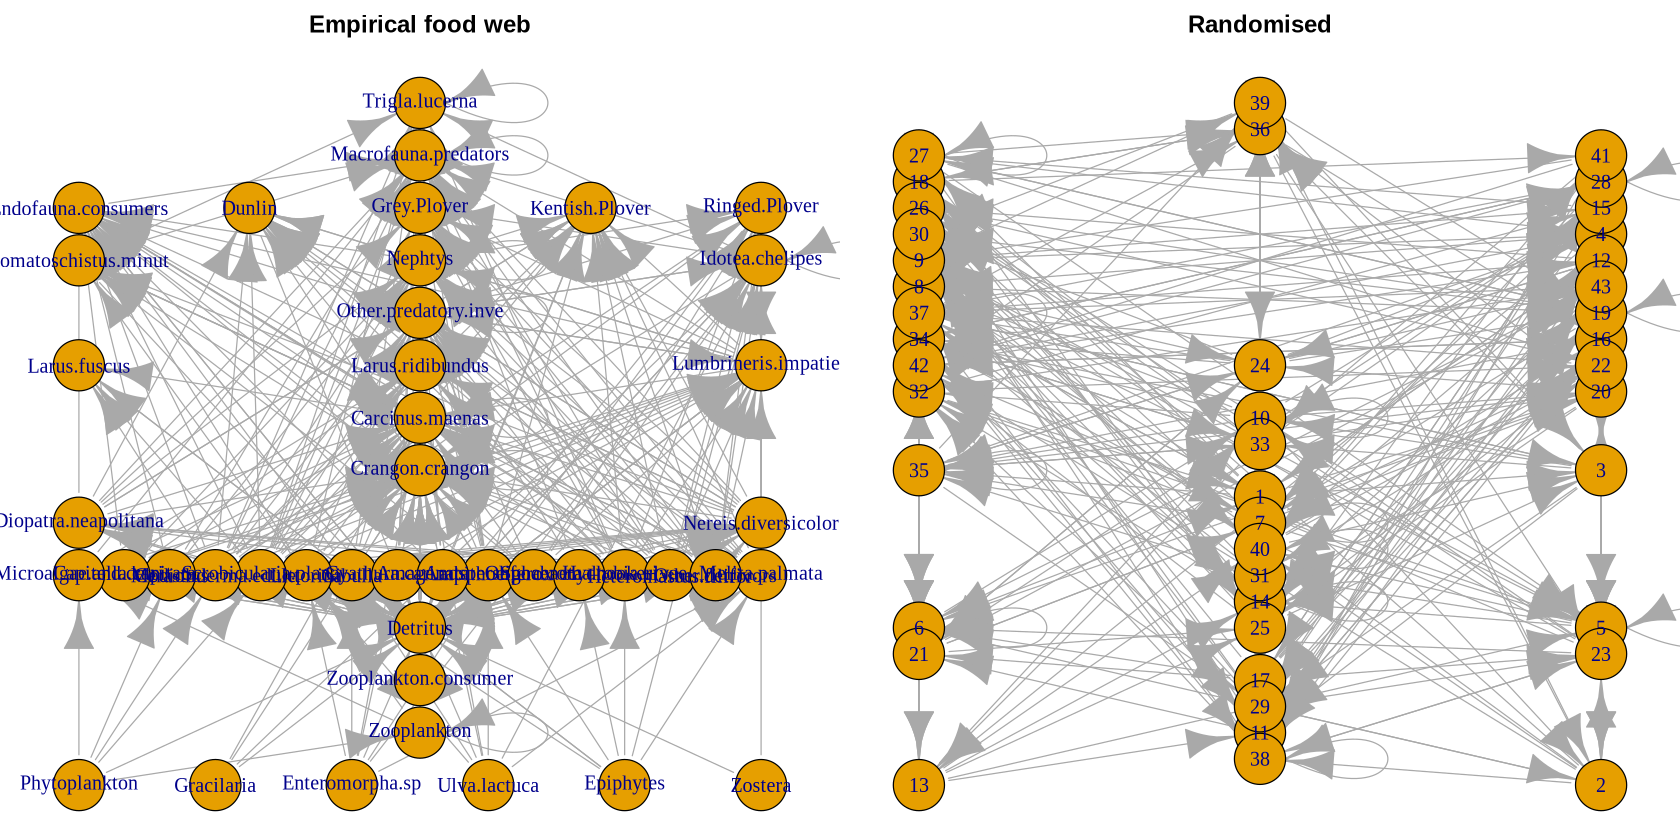

In [75]:
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2), mar = c(0, 0, 2, 0))
plot_as_flux(FW, main = "Empirical food web")
plot_as_flux(FW_rand1, main = "Randomised")

#### Rewiring unipartite networks
To generate a null model that keeps fixed not only $N$ and $L$, but also the degree sequence, (rewiring) we can use the *igraph* function `rewire()`

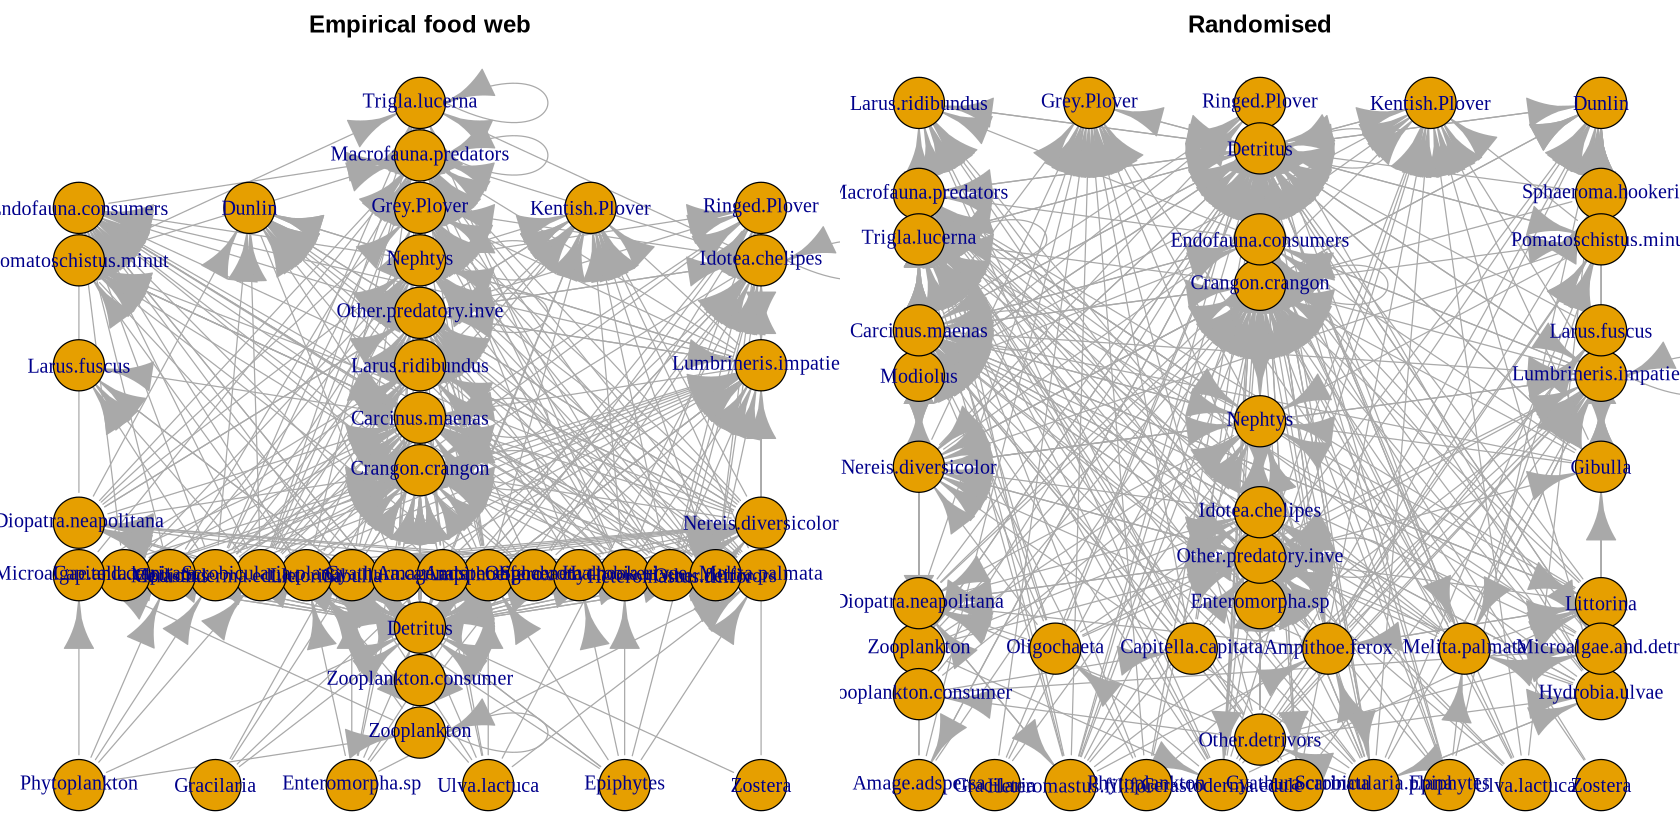

In [76]:
FW_rand2 <- igraph::rewire(FW, igraph::keeping_degseq(loops = TRUE,niter = 10 * ecount(FW)))
#we can see if they look similar .... 
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2), mar = c(0, 0, 2, 0))

plot_as_flux(FW, main = "Empirical food web")
plot_as_flux(FW_rand2, main = "Randomised")

In this case we don't need to plot the degree distribution as we know it is exactly the same!

### Bipartite networks

For bipartite networks we can use both *igraph* or *bipartite*. We will use *bipartete* for simplicity, as *igraph* generates graph objects, while *bipartite* generates matrices, that can then be used in the rest of functions.


#### Random bipartite networks

In this null model we keep fixed the number of specie in each guild ($N_a$,$N_p$) and the number of links ($L$). The function in *bipartite* is called `shuffle.web`. This creates L links randomly in a $N_a x N_p$ matrix, ensuring all nodes are connected. 
Bipartite doesen't have this as a function so we will do it in *igraph* and then translate the grpah to a matrix to be used in bipartite

We are going to see only the unweighted case (where each interaction has weight 1). the case of weighted interactions is more complex as one should also ensure connectance is fixed.

In [113]:
#get basic structural features
Na<-ncol(I)
Np<-nrow(I)
L <- sum(I>0)

B_rand1 <- igraph::sample_bipartite(Na, Np, type = "gnm", m = L)
I_rand1 <- t(igraph::as_biadjacency_matrix(B_rand1))

Let's see how they look like

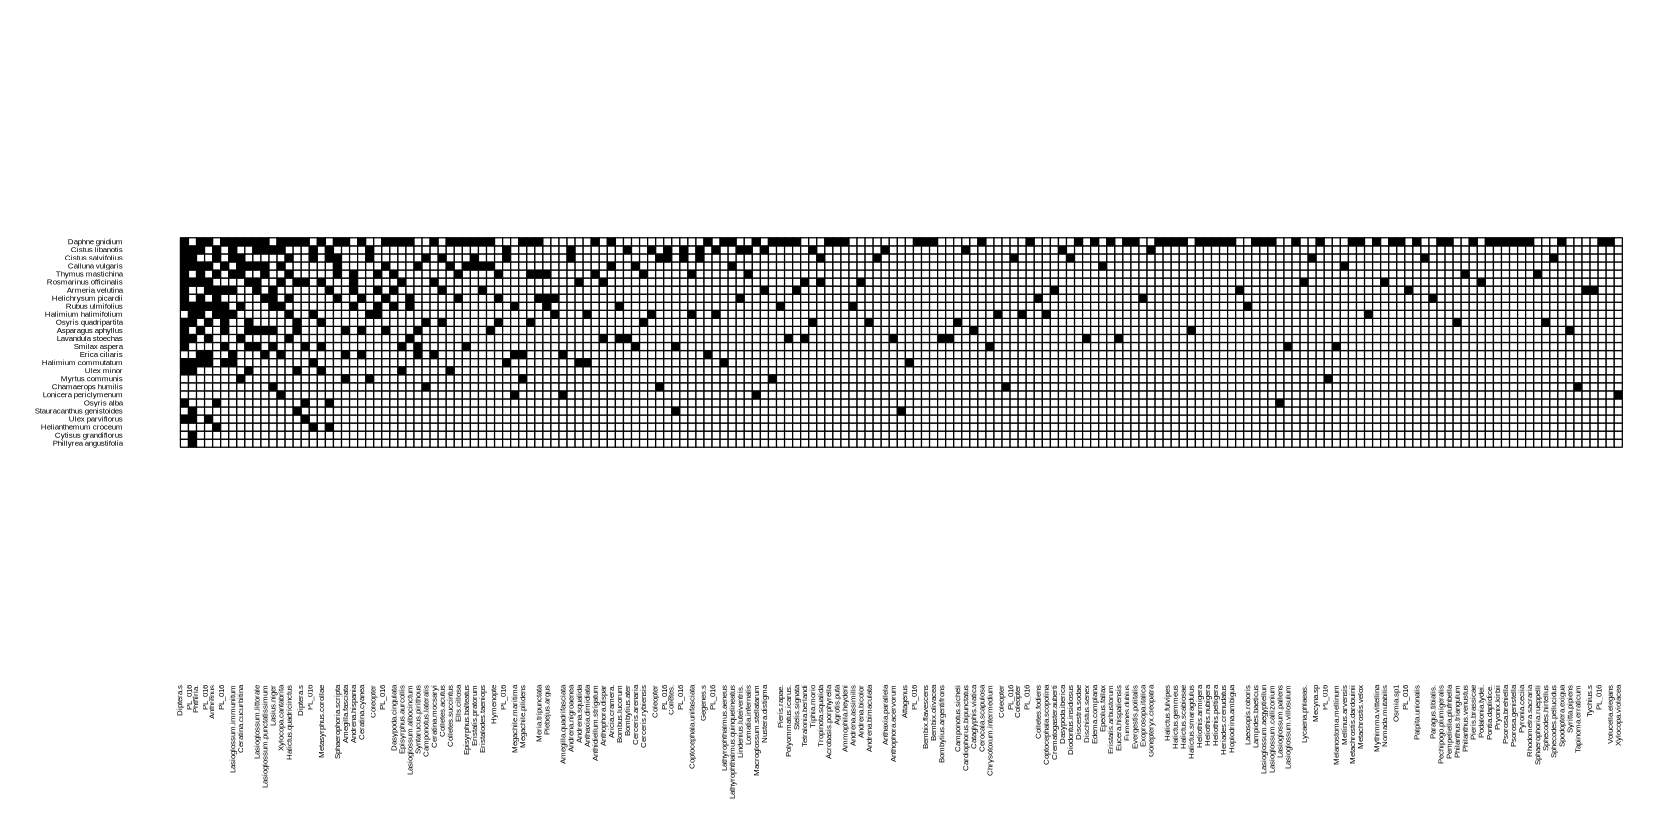

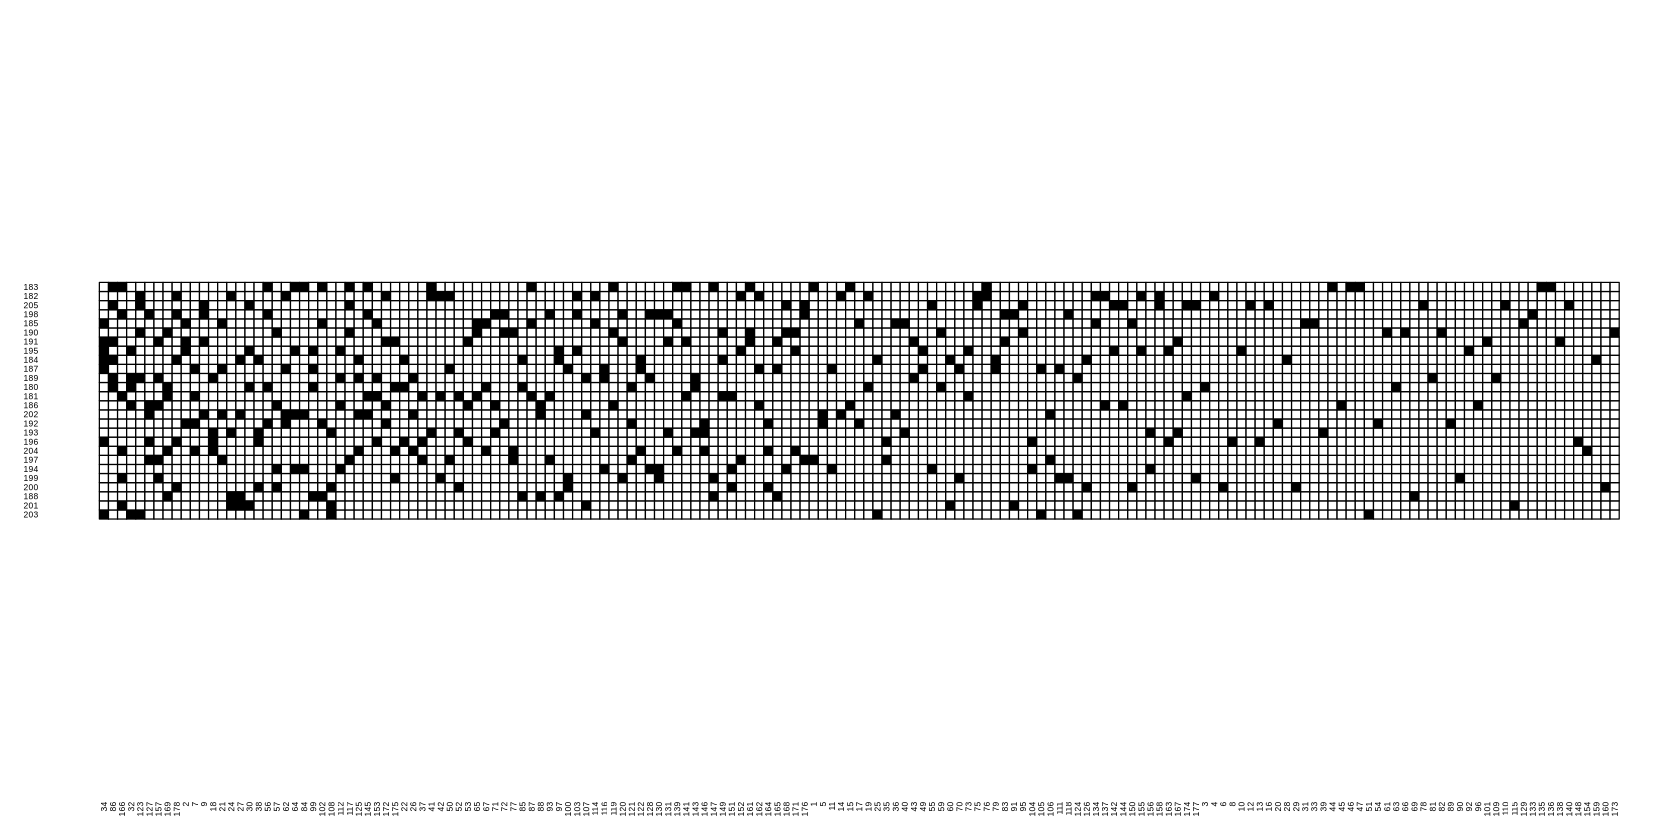

In [120]:
visweb((I), type = "nested",labsize = 4)
visweb((I_rand1), type = "nested",labsize = 4)

,Estimate,Std. Error,Pr(>|t|),R2,AIC
exponential,0.131972,0.02261598,0.0001648510,0.9136766,-6.507929
power law,1.688150,0.34683570,0.0006542521,0.8646535,-1.626031
truncated power law,-7.325820,1.24168901,0.0002291046,0.9867982,-26.615348
,Estimate,Std. Error,Pr(>|t|),R2,AIC
exponential,0.502446,0.06548786,0.000599367,0.9847182,-11.717057
power law,1.079685,0.23867728,0.006262033,0.9340171,-2.241386
truncated power law,-1.106386,0.28614105,0.018045960,0.9973278,-22.244127


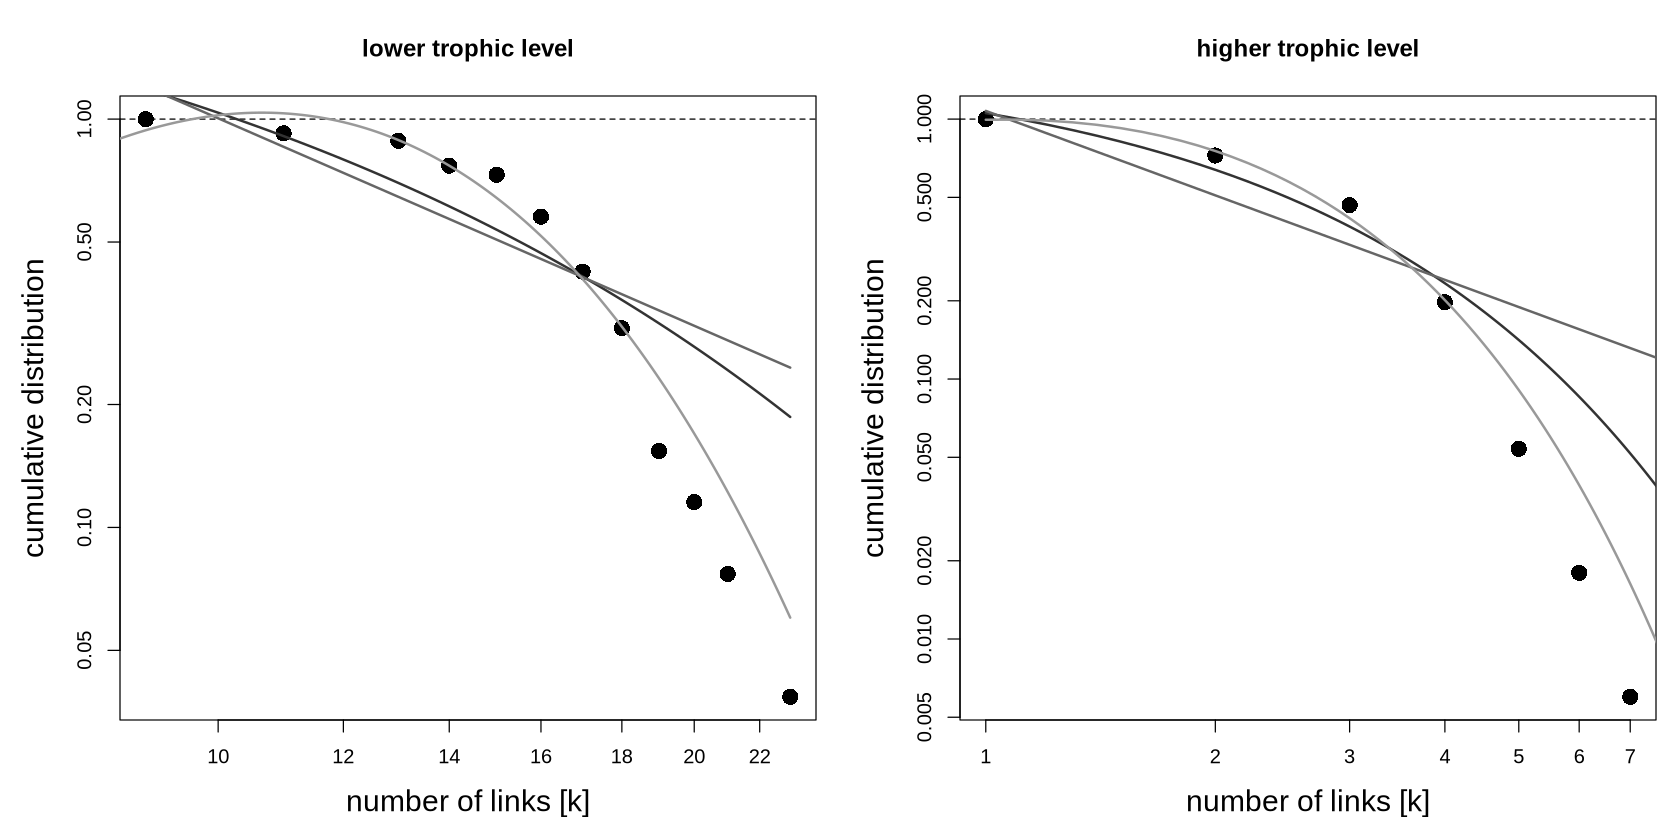

,Estimate,Std. Error,Pr(>|t|),R2,AIC
exponential,NA,NA,NA,NA,NA
power law,0.40593306,0.05682466,1.181815e-06,0.8607667,-13.34855
truncated power law,-0.09420376,0.07383114,2.191369e-01,0.9728122,-43.43417
,Estimate,Std. Error,Pr(>|t|),R2,AIC
exponential,0.6390216,0.04289371,1.224679e-08,0.9948334,-45.78959
power law,1.3245628,0.04273343,4.672958e-12,0.9975734,-57.47336
truncated power law,0.9200405,0.03051514,3.770559e-11,0.9998725,-97.00585


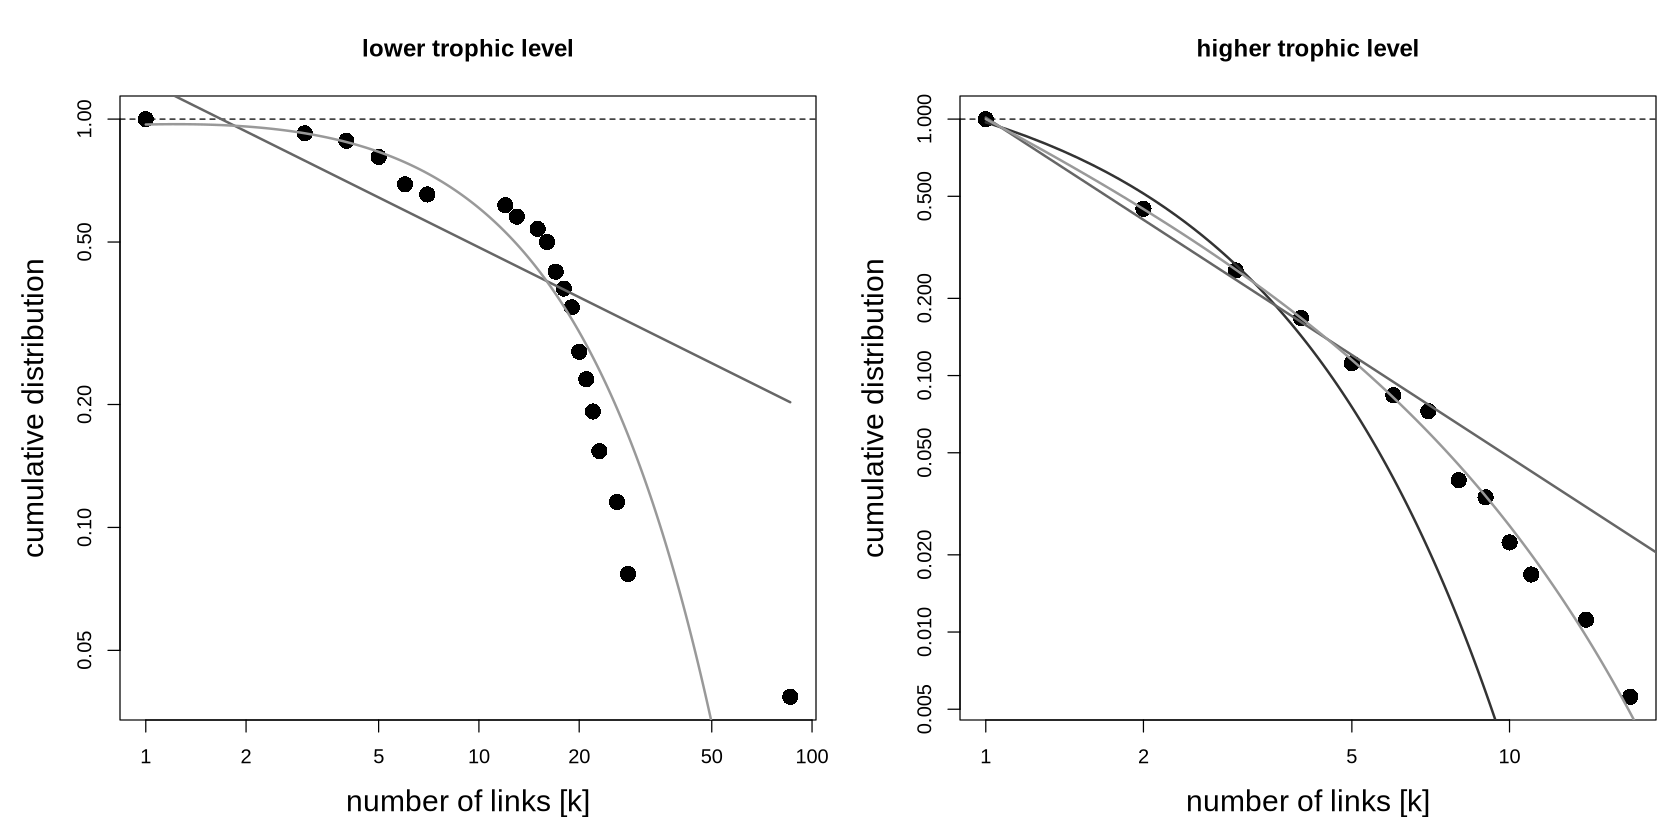

In [121]:
degreedistr(I_rand1)
degreedistr(I)

#### Rewiring bipartite networks

In this null model we keep fixed the number of plants $N_p$, animals $N_a$, interactions $L$, but more importantly, the degree sequence of the species (row sum, col sum). Biparte has several functions for this, but the one in vega is better, as it implements the curveball algorithm.



In [122]:
nm <- vegan::nullmodel(I, "curveball")
I_rand2 <- simulate(nm, nsim = 1, burnin = 1000)[, , 1]
dimnames(I_rand2) <- dimnames(I)

this one looks much more similar, and in fact have the sme degree distribution

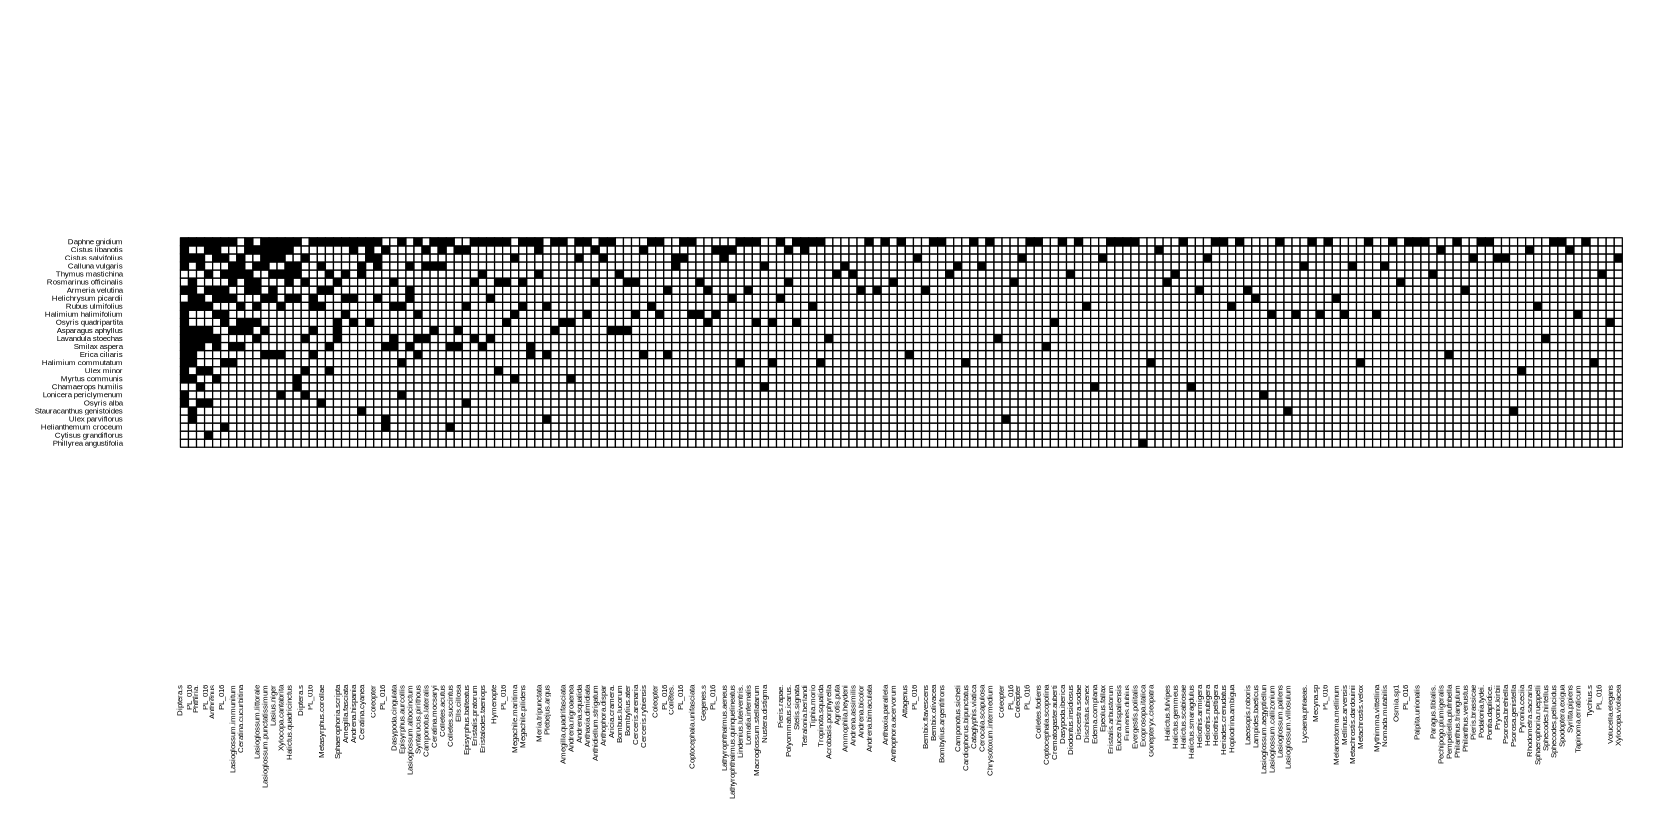

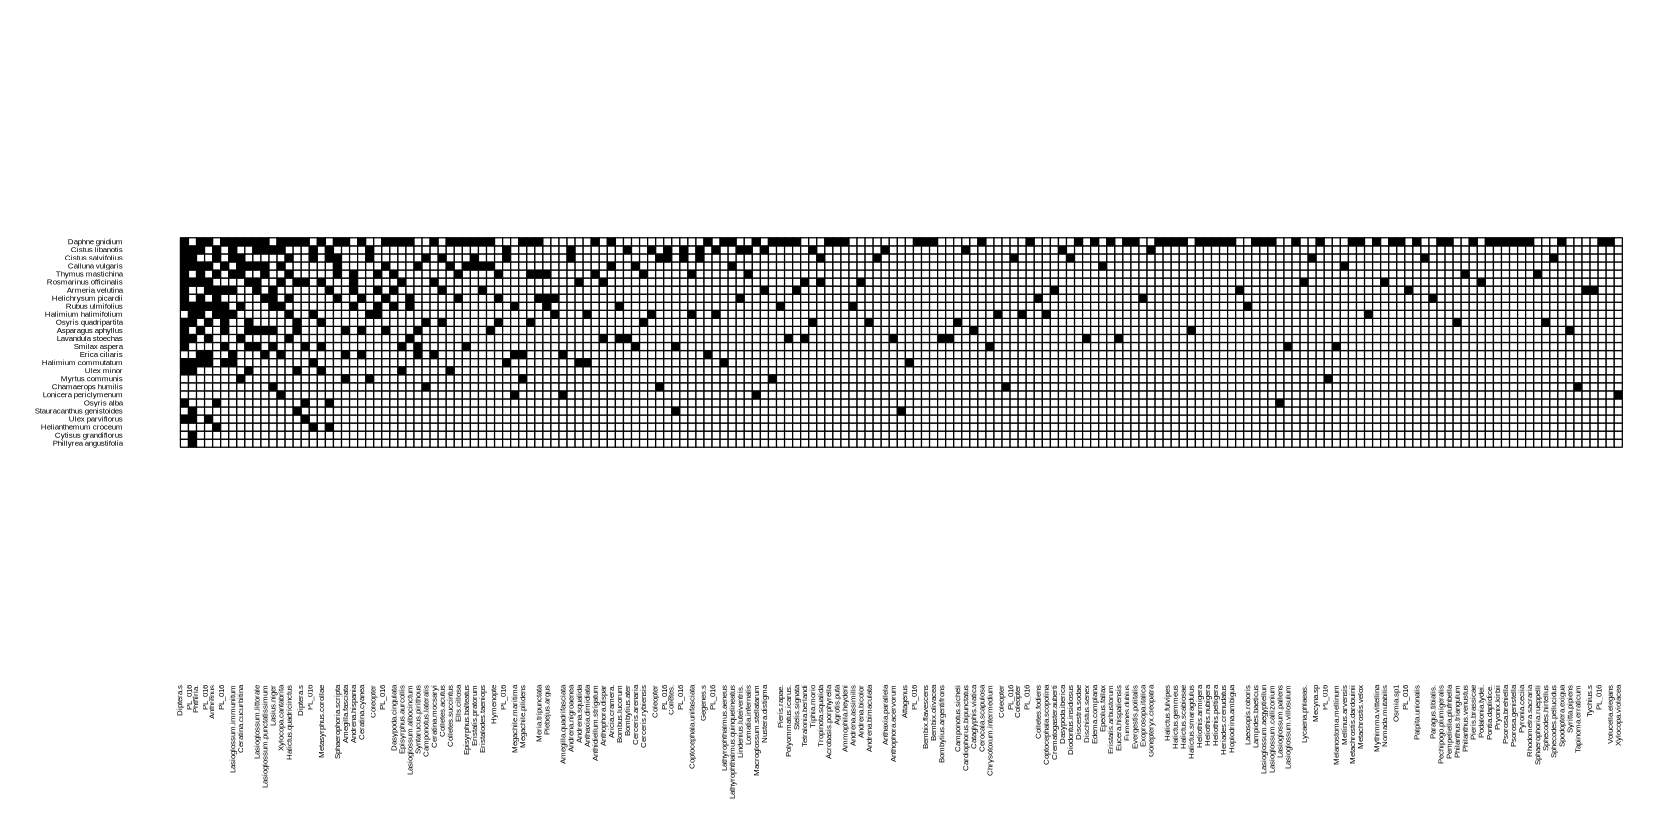

In [125]:
visweb((I_rand2), type = "nested",labsize = 4)
visweb((I), type = "nested",labsize = 4)


However, other structure related to how the network is connected can be lost

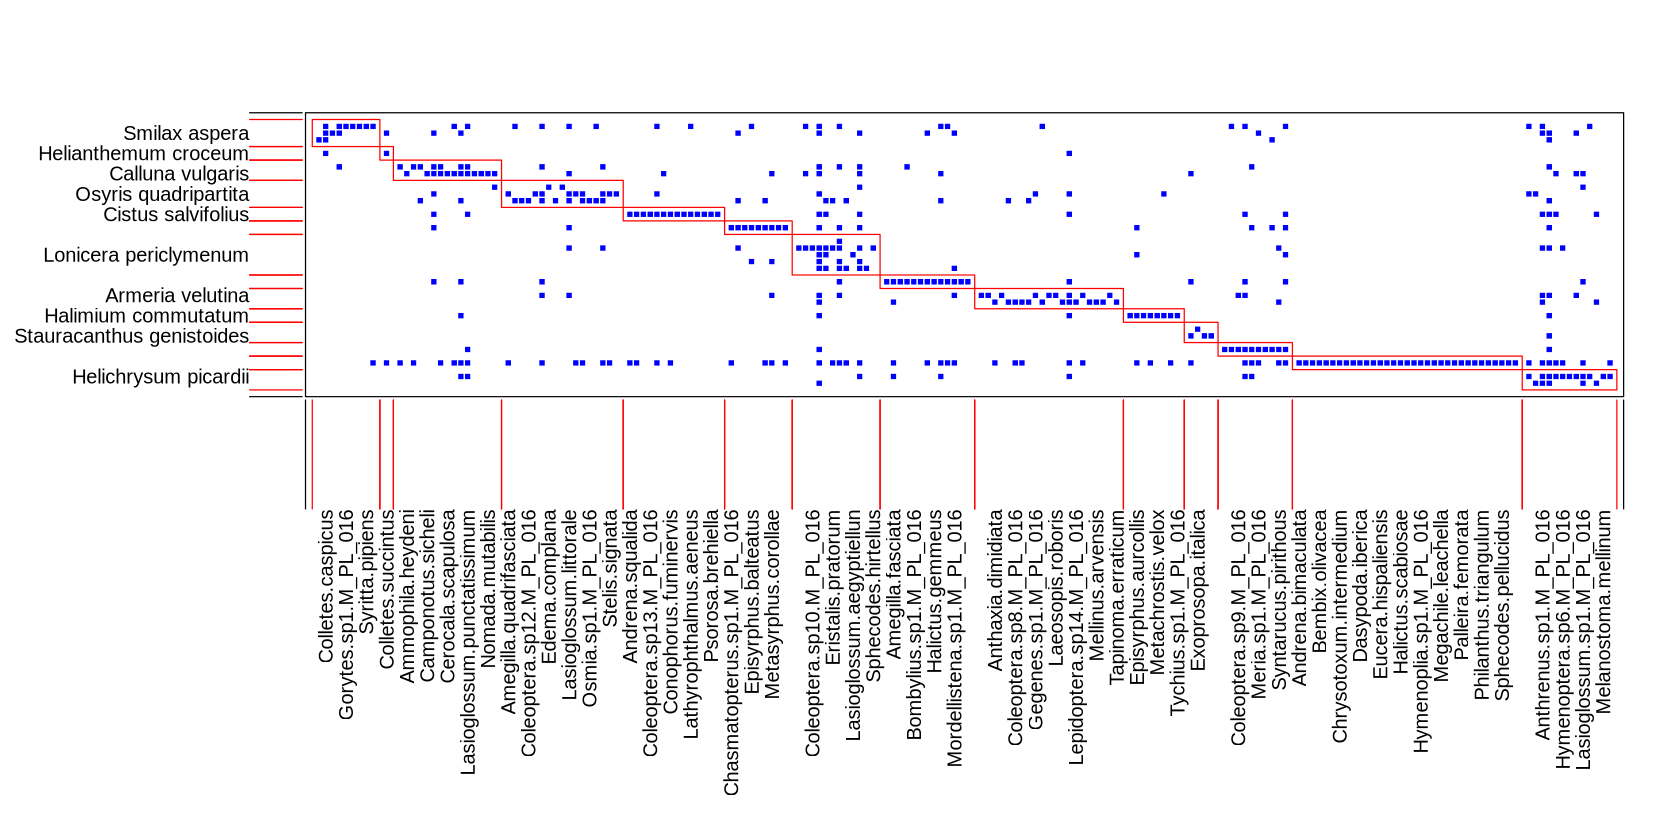

In [126]:
mod_rand2 <- bipartite::computeModules(I_rand2)   # finds bipartite modules
plotModuleWeb(mod_rand2)

## 4B Statistical significance:

Null model ensembles and z-score

### Unipartite networks 

Q_obs = 0.163, mean Q_rand = 0.136, z = 3.36, p = 0.000


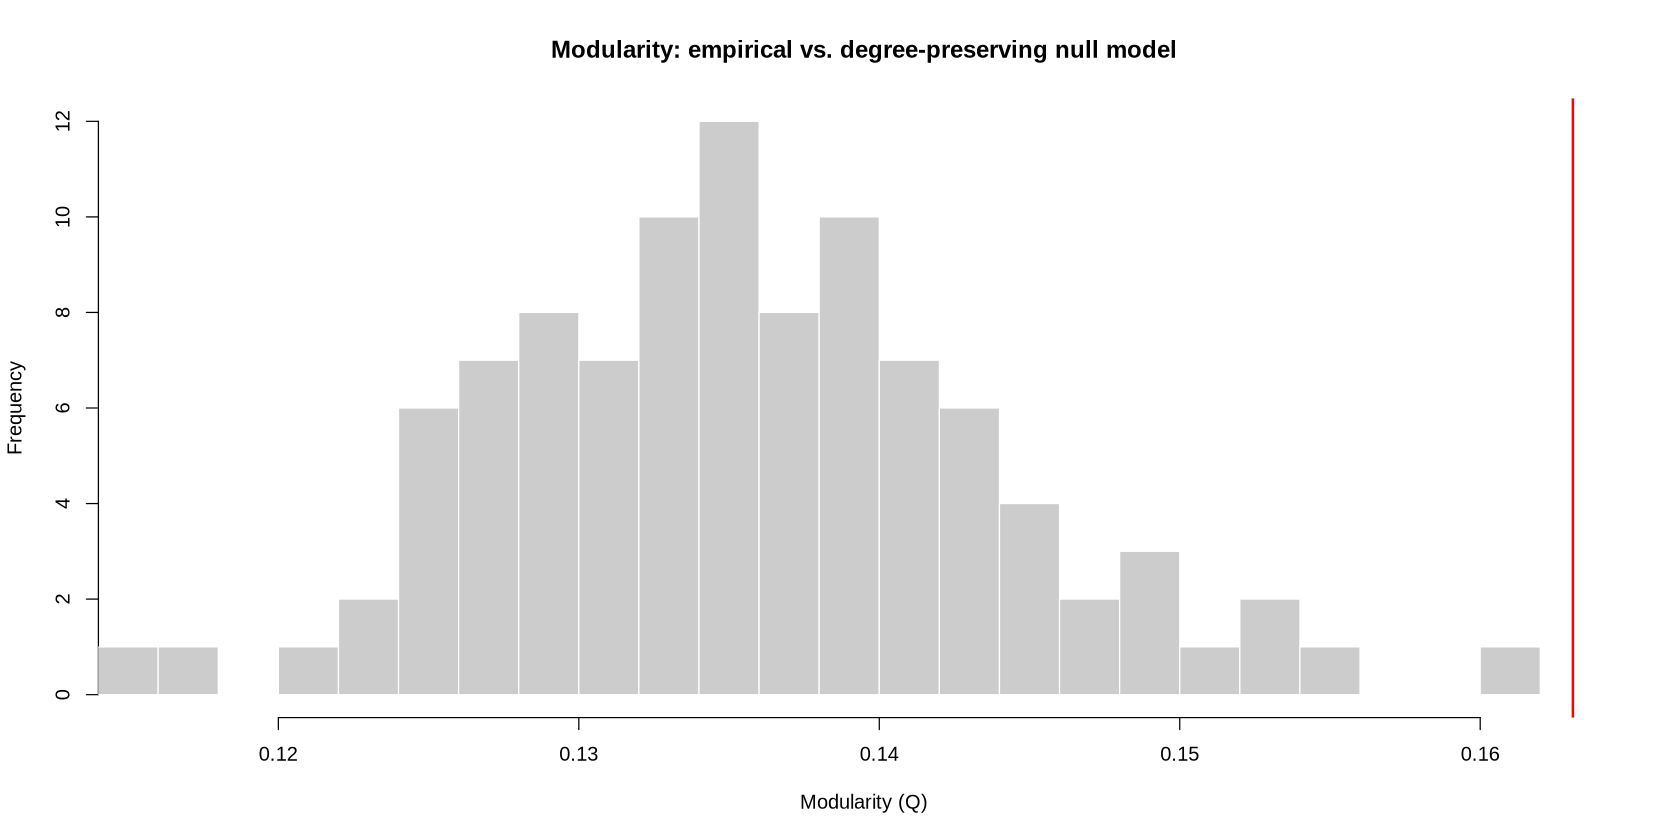

In [132]:
set.seed(1)
n_rand <- 100
L <- igraph::ecount(FW)
FW_bin <- igraph::delete_edge_attr(FW, "weight")

# modularity of the empirical food web
Q_obs <- igraph::modularity(
  igraph::cluster_louvain(igraph::as_undirected(FW_bin, mode = "collapse")))

# ensemble of degree-preserving randomisations
Q_rand <- replicate(n_rand, {
  r <- igraph::rewire(FW_bin, igraph::keeping_degseq(niter = 10 * L))
  igraph::modularity(
    igraph::cluster_louvain(igraph::as_undirected(r, mode = "collapse")))
})

# plot
hist(Q_rand, breaks = 20, col = "grey80", border = "white",
     xlim = range(c(Q_rand, Q_obs)),
     main = "Modularity: empirical vs. degree-preserving null model",
     xlab = "Modularity (Q)")
abline(v = Q_obs, col = "red", lwd = 2)

# z-score and empirical p-value
z <- (Q_obs - mean(Q_rand)) / sd(Q_rand)
p <- mean(Q_rand >= Q_obs)
cat(sprintf("Q_obs = %.3f, mean Q_rand = %.3f, z = %.2f, p = %.3f\n",
            Q_obs, mean(Q_rand), z, p))